# QAPINN for the 2D Steady Navier–Stokes Equations (Kovasznay Flow) — Full-Parity Study

**This notebook mirrors every component of the Burgers'/heat-equation studies** — the same six-configuration
experiment matrix, the same three XAI techniques (Fourier spectrum, McClean barren-plateau scan, activation
maps), the same weight-movement and quantum-only-variance diagnostics, the same verified analytical accuracy
benchmark, and the same 5-seed Stage C statistical confirmation. The differences are the physics (a coupled,
nonlinear, vector-valued system instead of a single scalar PDE) and the domain (2D steady-state `(x, y)`
instead of 1D time-dependent `(x, t)`).

**Why this is the hardest of the three PDE benchmarks in this project:** unlike Burgers' (1D, scalar, nonlinear)
and the heat equation (1D, scalar, linear), the incompressible Navier–Stokes system is **coupled and
vector-valued** — three unknowns (`u`, `v`, `p`), three governing equations (two momentum components plus the
incompressibility/continuity constraint), and a genuinely 2D spatial domain. There is no time axis: this is the
classic **Kovasznay flow** benchmark, an exact steady-state solution used throughout the PINN literature (Raissi
et al.-style benchmarks, DeepXDE, and numerous CFD papers) precisely because it is one of the few configurations
of the full nonlinear Navier–Stokes equations with a closed-form analytical solution.

**Governing equations** (steady, incompressible, non-dimensional, $\nu = 1/Re$):
$$u\,u_x + v\,u_y = -p_x + \nu\,(u_{xx}+u_{yy})$$
$$u\,v_x + v\,v_y = -p_y + \nu\,(v_{xx}+v_{yy})$$
$$u_x + v_y = 0 \quad \text{(continuity / incompressibility)}$$

**Exact solution (Kovasznay, 1948)**, on domain $\Omega = [-0.5, 1.0]\times[-0.5, 1.5]$ at $Re = 40$:
$$\lambda = \frac{Re}{2} - \sqrt{\frac{Re^2}{4} + 4\pi^2}, \qquad
u(x,y) = 1 - e^{\lambda x}\cos(2\pi y), \qquad
v(x,y) = \frac{\lambda}{2\pi} e^{\lambda x}\sin(2\pi y), \qquad
p(x,y) = \tfrac{1}{2}\left(1 - e^{2\lambda x}\right)$$

Dirichlet boundary conditions for `u` and `v` are taken directly from this exact solution on all four edges of
`Ω`; pressure is left unconstrained on the boundary (as is standard — it is only defined up to the additive
constant already fixed by this formula) and is instead checked against the exact solution in the accuracy
benchmark. **Verified symbolically with SymPy before this notebook was written**: substituting this solution into
the continuity equation and both momentum equations gives exactly zero symbolically, confirmed at $Re=40$, and
numeric spot-checks across the domain agree to floating-point precision (~1e-15).

**Architecture note:** the network for every model in this notebook maps `(x, y) → (u, v, p)` — 2 inputs, 3
outputs — versus the 2-input/1-output networks in the Burgers' and heat notebooks. **All classical hidden layers
in this notebook use a width of `[25, 25, 25, 25]`**, for every model (`C0`, `C0_Best`, and the classical
post-processing stack in every `Q1`–`Q5` QAPINN variant) — a deliberate, uniform change from the `[20, 20, 20,
20]` used in the companion notebooks, made specifically for this study. One consequence worth flagging:
`C0_Best_Classical_NS` is therefore **no longer wider** than `C0_Classical_NS` (both now use the same
`[25,25,25,25]` stack) — its only remaining distinguishing factor is a longer training budget
(`EPOCHS_CLASSICAL_BEST` vs `EPOCHS_MAIN`), not extra capacity. Keep that in mind when reading its results.

**Logging note:** every training run in this notebook prints progress **every 10 epochs** (`log_every=10`),
denser than the companion notebooks' `~epochs//5` default, since 10-epoch resolution is more useful for watching
a coupled 3-equation loss converge.

**Cross-notebook comparability:** the quantum circuit architectures for `Q1`–`Q5` are byte-for-byte identical to
the Burgers' and heat notebooks' — same qubit counts, same encodings, same ansätze. The McClean gradient-variance
results are therefore still directly comparable across all three notebooks.

## Cell 1 — Setup, GPU Check, and Reproducibility

Fixed `SEED = 42` (single-seed for the main matrix and most diagnostics; Stage C separately re-runs across 5
additional seeds), automatic GPU detection with a graceful CPU fallback for the classical (PyTorch) layers, and
PennyLane's `default.qubit` simulator for the quantum circuit -- run through **PennyLane's JAX interface**
(`interface="jax"`, `diff_method="backprop"`, JIT-compiled with `jax.jit`), so the state-vector simulation itself
runs on GPU whenever a CUDA-enabled JAX build is available on this machine. This is a change from a plain
`interface="torch"` + `qml.qnn.TorchLayer` setup (which pinned the quantum circuit to the CPU): the quantum layer
here is a custom `QuantumLayerJax` module that bridges PennyLane/JAX into the PyTorch autograd graph via
`jax.vjp`, so `QAPINN` is still trained end-to-end with a single PyTorch optimizer, but the quantum sub-circuit's
linear algebra can execute on the GPU alongside the classical layers.


In [10]:
%pip install pennylane

# ============================================================
# Setup, GPU check, reproducibility
# ============================================================
import os
import time
import math
import random
import numpy as np
import torch
import torch.nn as nn
import pennylane as qp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

sns.set_theme(style="whitegrid", palette="viridis")

GPU_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if GPU_DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    n_cores = os.cpu_count() or 1
    torch.set_num_threads(n_cores)
    print("No CUDA GPU found -- running on CPU. This is the costliest of the three PDE benchmarks per")
    print("epoch (coupled 3-equation residual, 2D second derivatives for two velocity components), so budget")
    print("more wall-clock time than the Burgers'/heat notebooks -- the Runtime Calibration cell below gives")
    print("a machine-specific estimate.")
    print(f"Detected {n_cores} CPU core(s); torch.set_num_threads({n_cores}) applied.")

# ------------------------------------------------------------
# JAX setup for the quantum circuit (PennyLane's "jax" interface).
# We do NOT force-install a CUDA-specific jax/jaxlib build here --
# guessing the wrong CUDA major version can silently break an existing,
# working GPU jax install. Instead: import what's already on the
# machine, tell JAX to prefer GPU if one shows up in jax.devices(),
# and print clear next steps if GPU jax isn't already present.
# ------------------------------------------------------------
try:
    import jax
    import jax.numpy as jnp
except ImportError:
    print("\nJAX not found -- installing CPU-only JAX as a fallback (%pip install jax jaxlib).")
    print("For GPU-accelerated JAX, install the CUDA build that matches this machine's CUDA")
    print("version yourself, e.g.: pip install -U \"jax[cuda12]\"  (see https://docs.jax.dev/en/latest/installation.html)")
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "jax", "jaxlib"], check=False)
    import jax
    import jax.numpy as jnp

try:
    jax.config.update("jax_platform_name", "gpu" if GPU_DEVICE == "cuda" else "cpu")
except Exception:
    pass

JAX_DEVICES = jax.devices()
JAX_GPU_AVAILABLE = any(d.platform == "gpu" for d in JAX_DEVICES)
QUANTUM_DEVICE = "gpu" if JAX_GPU_AVAILABLE else "cpu"

print(f"\nPyTorch : {torch.__version__}")
print(f"PennyLane: {qp.__version__}")
print(f"JAX      : {jax.__version__}")
print(f"JAX devices visible: {JAX_DEVICES}")
print(f"Device for classical layers: {GPU_DEVICE.upper()}")
print(f"Quantum circuit device (PennyLane default.qubit via JAX interface): {QUANTUM_DEVICE.upper()}")
if GPU_DEVICE == "cuda" and not JAX_GPU_AVAILABLE:
    print("\nNote: a CUDA GPU is available for PyTorch, but JAX only sees CPU devices, so the quantum")
    print("circuit will still run on CPU this session. To enable GPU for the quantum circuit too, install a")
    print("CUDA-matched JAX build, e.g.: pip install -U \"jax[cuda12]\"  (pick the cuda1X tag matching this")
    print("machine's CUDA toolkit), then restart the runtime.")


GPU: Tesla T4
GPU Memory: 15.64 GB

PyTorch : 2.11.0+cu128
PennyLane: 0.45.1
JAX      : 0.7.2
JAX devices visible: [CudaDevice(id=0)]
Device for classical layers: CUDA
Quantum circuit device (PennyLane default.qubit via JAX interface): GPU


**Reading the output:** either `GPU: ...` or `No CUDA GPU found` is a correct, expected outcome for the
classical layers -- the rest of the notebook adapts automatically either way. Separately, `Quantum circuit
device: GPU` or `CPU` tells you whether PennyLane's JAX-backed `default.qubit` simulation is itself running on
the GPU; if it says `CPU` despite a CUDA GPU being present, follow the printed instructions to install a
CUDA-matched `jax[cudaXX]` build and restart the runtime.


## Local Run Configuration

Sets the epoch budget and gates the expensive multi-seed Stage C sweep, exactly as in the companion notebooks.
Epoch *counts* are kept identical to the heat/Burgers' notebooks for cross-notebook comparability, even though
each epoch here does noticeably more work (three coupled residual equations instead of one).

In [11]:
# ============================================================
# Local run configuration -- works for both GPU and CPU-only machines.
# ============================================================
FAST_LOCAL_MODE = False

EPOCHS_MAIN = 500 if FAST_LOCAL_MODE else 5000              # C0_Classical_NS + Q1-Q5
EPOCHS_CLASSICAL_BEST = 800 if FAST_LOCAL_MODE else 10000    # C0_Best_Classical_NS

RUN_STAGE_C = True   # 5-seed x 6-config multi-seed sweep (30 full training runs) -- opt in only

LOG_EVERY_N_EPOCHS = 10   # every training run in this notebook logs progress every 10 epochs

print(f"FAST_LOCAL_MODE = {FAST_LOCAL_MODE}")
print(f"EPOCHS_MAIN = {EPOCHS_MAIN}  (same budget as the companion notebooks)")
print(f"EPOCHS_CLASSICAL_BEST = {EPOCHS_CLASSICAL_BEST}  (same budget as the companion notebooks)")
print(f"RUN_STAGE_C = {RUN_STAGE_C}")
print(f"LOG_EVERY_N_EPOCHS = {LOG_EVERY_N_EPOCHS}")

FAST_LOCAL_MODE = False
EPOCHS_MAIN = 5000  (same budget as the companion notebooks)
EPOCHS_CLASSICAL_BEST = 10000  (same budget as the companion notebooks)
RUN_STAGE_C = True
LOG_EVERY_N_EPOCHS = 10


**Reading the output:** confirms the settings that will apply below. Revisit after the Runtime Calibration cell (after Cell 6) gives a machine-specific estimate.

## Cell 2 — Physics Utilities for the 2D Steady Navier–Stokes Equations (Kovasznay Flow)

Same structure as the companion notebooks' Cell 2 — `PHYSICS_CONFIG`, collocation/boundary sampling, a residual
function using second-order PyTorch autograd, and a combined weighted loss. There is **no initial-condition
term** here (the problem is steady-state, not time-dependent) — the third loss component is instead
**continuity** (mass conservation), which has no analogue in either the Burgers' or heat notebooks and is the
defining extra constraint of a real Navier–Stokes system versus a single scalar convection-diffusion equation.

In [12]:
# ============================================================
# Physics: 2D steady incompressible Navier-Stokes (Kovasznay flow)
#   u u_x + v u_y = -p_x + nu*(u_xx + u_yy)     (x-momentum)
#   u v_x + v v_y = -p_y + nu*(v_xx + v_yy)     (y-momentum)
#   u_x + v_y = 0                                (continuity)
# Exact solution (Kovasznay, 1948 -- verified symbolically to satisfy
# the above exactly, at Re=40, before this notebook was written):
#   lambda = Re/2 - sqrt(Re^2/4 + 4*pi^2)
#   u(x,y) = 1 - exp(lambda*x) * cos(2*pi*y)
#   v(x,y) = (lambda / (2*pi)) * exp(lambda*x) * sin(2*pi*y)
#   p(x,y) = 0.5 * (1 - exp(2*lambda*x))
# Domain: x in [-0.5, 1.0], y in [-0.5, 1.5]  (standard PINN benchmark domain)
# ============================================================
PHYSICS_CONFIG = {
    "Re": 40.0,
    "x_min": -0.5, "x_max": 1.0,
    "y_min": -0.5, "y_max": 1.5,
    "n_collocation": 2601,
    "n_boundary": 400,
}
LOSS_WEIGHTS = {"momentum": 1.0, "continuity": 1.0, "bc": 1.0}

NU = 1.0 / PHYSICS_CONFIG["Re"]
LAMBDA = PHYSICS_CONFIG["Re"] / 2.0 - math.sqrt(PHYSICS_CONFIG["Re"] ** 2 / 4.0 + 4.0 * math.pi ** 2)


def exact_solution(x, y):
    u = 1.0 - torch.exp(LAMBDA * x) * torch.cos(2 * math.pi * y)
    v = (LAMBDA / (2 * math.pi)) * torch.exp(LAMBDA * x) * torch.sin(2 * math.pi * y)
    p = 0.5 * (1.0 - torch.exp(2 * LAMBDA * x))
    return torch.cat([u, v, p], dim=1)


def sample_collocation(n=None, device="cpu"):
    n = n or PHYSICS_CONFIG["n_collocation"]
    x = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"])
    y = torch.empty(n, 1, device=device).uniform_(PHYSICS_CONFIG["y_min"], PHYSICS_CONFIG["y_max"])
    return x, y


def sample_boundary(n=None, device="cpu"):
    """Samples the perimeter of the rectangular domain (4 edges) and reads
    the Dirichlet u, v values for those points off the exact solution."""
    n = n or PHYSICS_CONFIG["n_boundary"]
    n_side = max(1, n // 4)
    xmin, xmax = PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"]
    ymin, ymax = PHYSICS_CONFIG["y_min"], PHYSICS_CONFIG["y_max"]

    y_lr = torch.empty(n_side, 1, device=device).uniform_(ymin, ymax)
    x_left = torch.full((n_side, 1), xmin, device=device)
    x_right = torch.full((n_side, 1), xmax, device=device)

    x_bt = torch.empty(n_side, 1, device=device).uniform_(xmin, xmax)
    y_bottom = torch.full((n_side, 1), ymin, device=device)
    y_top = torch.full((n_side, 1), ymax, device=device)

    xb = torch.cat([x_left, x_right, x_bt, x_bt], dim=0)
    yb = torch.cat([y_lr, y_lr, y_bottom, y_top], dim=0)
    uvp_b = exact_solution(xb, yb)
    return xb, yb, uvp_b[:, 0:1], uvp_b[:, 1:2]


def navier_stokes_residual(model, x, y):
    x = x.clone().requires_grad_(True)
    y = y.clone().requires_grad_(True)
    out = model(x, y)
    u, v, p = out[:, 0:1], out[:, 1:2], out[:, 2:3]

    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_y = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    u_yy = torch.autograd.grad(u_y, y, torch.ones_like(u_y), create_graph=True)[0]

    v_x = torch.autograd.grad(v, x, torch.ones_like(v), create_graph=True)[0]
    v_y = torch.autograd.grad(v, y, torch.ones_like(v), create_graph=True)[0]
    v_xx = torch.autograd.grad(v_x, x, torch.ones_like(v_x), create_graph=True)[0]
    v_yy = torch.autograd.grad(v_y, y, torch.ones_like(v_y), create_graph=True)[0]

    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]
    p_y = torch.autograd.grad(p, y, torch.ones_like(p), create_graph=True)[0]

    continuity = u_x + v_y
    momentum_x = u * u_x + v * u_y + p_x - NU * (u_xx + u_yy)
    momentum_y = u * v_x + v * v_y + p_y - NU * (v_xx + v_yy)
    return continuity, momentum_x, momentum_y


def compute_losses(model, device="cpu"):
    x_f, y_f = sample_collocation(device=device)
    continuity, mom_x, mom_y = navier_stokes_residual(model, x_f, y_f)
    loss_continuity = torch.mean(continuity ** 2)
    loss_pde = torch.mean(mom_x ** 2) + torch.mean(mom_y ** 2)   # "pde" = momentum residual loss

    xb, yb, ub, vb = sample_boundary(device=device)
    pred_b = model(xb, yb)
    loss_bc = torch.mean((pred_b[:, 0:1] - ub) ** 2) + torch.mean((pred_b[:, 1:2] - vb) ** 2)

    total = (LOSS_WEIGHTS["momentum"] * loss_pde
             + LOSS_WEIGHTS["continuity"] * loss_continuity
             + LOSS_WEIGHTS["bc"] * loss_bc)

    all_res = torch.cat([continuity.abs().flatten(), mom_x.abs().flatten(), mom_y.abs().flatten()])
    return {
        "total": total, "pde": loss_pde, "continuity": loss_continuity, "bc": loss_bc,
        "mean_residual": all_res.mean(), "max_residual": all_res.max(),
    }

print(f"Physics utilities loaded. Re = {PHYSICS_CONFIG['Re']:.0f}, nu = {NU:.4f}, lambda = {LAMBDA:.4f}")

Physics utilities loaded. Re = 40, nu = 0.0250, lambda = -0.9637


**Reading the output:** confirms `Re = 40`, the derived `nu` and `lambda`, and that the functions loaded -- nothing else to check yet.

## Cell 3 — Model Definitions: ClassicalPINN and QAPINN

Same two-class design as before -- input `(x, y)`, VQC replacing only the first hidden layer -- with the output
still **3-dimensional** (`u, v, p`) and every classical hidden stack at `[25, 25, 25, 25]`. The one structural
change in this version: the quantum circuit (`build_qnode`) is built with PennyLane's **`interface="jax"`**
instead of `interface="torch"`, JIT-compiled and batched with `jax.jit(jax.vmap(...))`, and wrapped into the
model via a custom `QuantumLayerJax` module (a `torch.autograd.Function` using `jax.vjp` to bridge JAX's
gradients back into PyTorch's autograd graph) instead of `qml.qnn.TorchLayer`. Externally it behaves the same way
(same `.weights` parameter name, same forward-hook-ability, same `n_qubits`/`n_qlayers`/`encoding`/`ansatz`
options), so every downstream cell (training loop, XAI suite, weight-movement checks) needs no changes. The
quantum circuits themselves (`Q1`-`Q5`) are architecturally untouched, so McClean/Fourier results stay directly
comparable across notebooks.


In [13]:
# ============================================================
# Models: Classical PINN (full GPU/CPU) and QAPINN (hybrid, quantum
# circuit executed via PennyLane's JAX interface, GPU-capable)
# ============================================================
ACTIVATIONS = {"tanh": nn.Tanh, "relu": nn.ReLU, "gelu": nn.GELU, "silu": nn.SiLU, "elu": nn.ELU}

class ClassicalPINN(nn.Module):
    """Baseline: FC 2 -> 25 -> 25 -> 25 -> 25 -> 3."""
    def __init__(self, layers=(2, 25, 25, 25, 25, 3), activation="tanh", initializer="xavier"):
        super().__init__()
        self.layers = layers
        act = ACTIVATIONS[activation.lower()]
        modules = []
        for i in range(len(layers) - 1):
            modules.append(nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                modules.append(act())
        self.net = nn.Sequential(*modules)
        self._init_weights(initializer)

    def _init_weights(self, initializer):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if initializer == "xavier":
                    nn.init.xavier_normal_(m.weight)
                elif initializer == "kaiming":
                    nn.init.kaiming_normal_(m.weight)
                else:
                    nn.init.normal_(m.weight, 0, 0.02)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        return self.net(torch.cat([x, y], dim=1))

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

SUPPORTED_ENCODINGS = ["angle", "reupload"]
SUPPORTED_ANSATZ = ["basic_entangler", "strongly_entangling"]

def build_qnode(n_qubits, n_layers, encoding="angle", ansatz="basic_entangler"):
    """Returns a single-sample PennyLane QNode using the JAX interface."""
    assert encoding in SUPPORTED_ENCODINGS, f"Unsupported encoding: {encoding}"
    assert ansatz in SUPPORTED_ANSATZ, f"Unsupported ansatz: {ansatz}"
    dev = qp.device("default.qubit", wires=n_qubits)

    def apply_ansatz(weights):
        if ansatz == "basic_entangler":
            qp.BasicEntanglerLayers(weights, wires=range(n_qubits))
        else:
            qp.StronglyEntanglingLayers(weights, wires=range(n_qubits))

    @qp.qnode(dev, interface="jax", diff_method="backprop")
    def circuit(inputs, weights):
        if encoding == "reupload":
            for layer in range(n_layers):
                qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
                apply_ansatz(weights[layer:layer + 1])
        else:
            qp.AngleEmbedding(inputs, wires=range(n_qubits), rotation="Y")
            apply_ansatz(weights)
        return [qp.expval(qp.PauliZ(i)) for i in range(n_qubits)]

    return circuit

def _torch_to_jax(t):
    t = t.contiguous()
    if t.device.type == "cuda" and JAX_GPU_AVAILABLE:
        try:
            return jax.dlpack.from_dlpack(torch.utils.dlpack.to_dlpack(t))
        except Exception:
            pass
    return jnp.asarray(t.detach().cpu().numpy())

def _jax_to_torch(a, like):
    if like.device.type == "cuda" and JAX_GPU_AVAILABLE:
        try:
            out = torch.utils.dlpack.from_dlpack(jax.dlpack.to_dlpack(a))
            return out.to(dtype=like.dtype, device=like.device)
        except Exception:
            pass
    return torch.as_tensor(np.asarray(a), dtype=like.dtype, device=like.device)

class _QuantumJaxFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights, circuit_fn):
        inputs_d, weights_d = inputs.detach(), weights.detach()
        inputs_jax = _torch_to_jax(inputs_d)
        weights_jax = _torch_to_jax(weights_d)
        out_jax, vjp_fn = jax.vjp(circuit_fn, inputs_jax, weights_jax)
        ctx.vjp_fn = vjp_fn
        ctx.inputs_like = inputs_d
        ctx.weights_like = weights_d
        return _jax_to_torch(out_jax, inputs_d)

    @staticmethod
    def backward(ctx, grad_output):
        grad_output_jax = _torch_to_jax(grad_output.detach())
        grad_inputs_jax, grad_weights_jax = ctx.vjp_fn(grad_output_jax)
        grad_inputs = _jax_to_torch(grad_inputs_jax, ctx.inputs_like)
        grad_weights = _jax_to_torch(grad_weights_jax, ctx.weights_like)
        return grad_inputs, grad_weights, None

class QuantumLayerJax(nn.Module):
    def __init__(self, single_circuit, weight_shape):
        super().__init__()

        def stacked_circuit(inputs, weights):
            return jnp.stack(single_circuit(inputs, weights))

        self.batched_circuit = jax.jit(jax.vmap(stacked_circuit, in_axes=(0, None)))
        self.weights = nn.Parameter(torch.empty(weight_shape).uniform_(-np.pi, np.pi))

    def forward(self, inputs):
        squeeze = inputs.dim() == 1
        if squeeze:
            inputs = inputs.unsqueeze(0)
        out = _QuantumJaxFunction.apply(inputs, self.weights, self.batched_circuit)
        return out.squeeze(0) if squeeze else out

class QAPINN(nn.Module):
    def __init__(self, n_qubits=3, n_qlayers=3, classical_hidden=(25, 25, 25, 25),
                 encoding="angle", ansatz="basic_entangler", activation="tanh"):
        super().__init__()
        self.n_qubits, self.n_qlayers = n_qubits, n_qlayers
        self.encoding, self.ansatz = encoding, ansatz
        circuit = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
        weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
        self.quantum_layer = QuantumLayerJax(circuit, weight_shape)
        self.input_projection = nn.Sequential(nn.Linear(2, 32), nn.Tanh(), nn.Linear(32, n_qubits))
        act = ACTIVATIONS[activation.lower()]
        modules, prev = [], n_qubits
        for h in classical_hidden:
            modules += [nn.Linear(prev, h), act()]
            prev = h
        modules.append(nn.Linear(prev, 3))
        self.postprocessing = nn.Sequential(*modules)

    def to(self, device):
        self.input_projection.to(device)
        self.postprocessing.to(device)
        self.quantum_layer.to(device)
        return self

    def forward(self, x, y):
        inputs = torch.cat([x, y], dim=1)
        projected = self.input_projection(inputs)
        quantum_out = self.quantum_layer(projected)
        # Fixed: Handle cases where JAX/PennyLane batching might transpose dimensions
        if quantum_out.shape[0] == self.n_qubits and quantum_out.shape[1] == projected.shape[0]:
            quantum_out = quantum_out.T
        return self.postprocessing(quantum_out)

    def num_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

print("Models redefined with corrected dimension handling in QAPINN forward pass.")

Models redefined with corrected dimension handling in QAPINN forward pass.


**Reading the output:** confirms both classes loaded without error, and the width/output-dim change.

## Cell 4 — Training Loop with Dual Gradient Tracking

Identical to the companion notebooks' Cell 4 — Adam + `ReduceLROnPlateau`, gradient clipping, and both a
whole-model (`grad_var`) and quantum-layer-only (`q_var`) gradient variance logged every epoch — with the
`"ic"` history key replaced by `"continuity"` (see Cell 2), and a default `log_every=10` per this notebook's
denser-logging requirement.

In [14]:
# ============================================================
# Training loop (shared by all experiments)
# ============================================================
TRAIN_CONFIG = {
    "learning_rate": 1e-3,
    "epochs": EPOCHS_MAIN,
    "scheduler_factor": 0.5,
    "scheduler_patience": 300,
    "grad_clip_norm": 1.0,
}


def train(model, epochs, device, log_every=LOG_EVERY_N_EPOCHS):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=TRAIN_CONFIG["learning_rate"])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min",
        factor=TRAIN_CONFIG["scheduler_factor"],
        patience=TRAIN_CONFIG["scheduler_patience"],
    )
    history = {k: [] for k in [
        "epoch", "total", "pde", "continuity", "bc", "mean_residual", "max_residual", "lr",
        "grad_norm", "grad_variance", "quantum_grad_norm", "quantum_grad_variance"
    ]}
    start = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        losses = compute_losses(model, device=device)
        losses["total"].backward()

        grad_norm, grad_var = compute_grad_variance(model)
        if hasattr(model, "quantum_layer"):
            q_norm, q_var = compute_grad_variance(model, target_params=model.quantum_layer.parameters())
        else:
            q_norm, q_var = grad_norm, grad_var

        torch.nn.utils.clip_grad_norm_(model.parameters(), TRAIN_CONFIG["grad_clip_norm"])
        optimizer.step()
        scheduler.step(losses["total"])

        history["epoch"].append(epoch)
        for k in ["total", "pde", "continuity", "bc", "mean_residual", "max_residual"]:
            history[k].append(losses[k].item())
        history["lr"].append(optimizer.param_groups[0]["lr"])
        history["grad_norm"].append(grad_norm)
        history["grad_variance"].append(grad_var)
        history["quantum_grad_norm"].append(q_norm)
        history["quantum_grad_variance"].append(q_var)

        if epoch == 1 or epoch % log_every == 0:
            print(f"[{time.time()-start:6.1f}s] Epoch {epoch:5d}/{epochs} "
                  f"| total={history['total'][-1]:.6f} momentum={history['pde'][-1]:.6f} "
                  f"continuity={history['continuity'][-1]:.6f} bc={history['bc'][-1]:.6f} "
                  f"| grad_var={grad_var:.2e} | q_var={q_var:.2e}")

    elapsed = time.time() - start
    print(f"Done in {elapsed:.2f}s\n")
    return history, elapsed

print(f"Training loop ready with detailed quantum gradient tracking. Default log_every={LOG_EVERY_N_EPOCHS}.")

Training loop ready with detailed quantum gradient tracking. Default log_every=10.


**Reading the output:** defines `train()` -- nothing to interpret until Cell 6 runs it.

## Cell 5 — Gradient Variance Helper Function

Identical to the companion notebooks. `compute_grad_variance(model, target_params=None)` flattens the requested
parameters' `.grad` tensors and returns their L2 norm and variance -- used both by the training loop above (via
`target_params=model.quantum_layer.parameters()`) and by the McClean scan later (via a fixed input, no training).

In [15]:
# ============================================================
# Gradient variance tracking (per-epoch, per-parameter-group)
# ============================================================
def compute_grad_variance(model, target_params=None):
    params = target_params if target_params is not None else model.parameters()
    grads = []
    for p in params:
        if p.grad is not None:
            grads.append(p.grad.detach().cpu().flatten())
    if not grads:
        return 0.0, 0.0
    all_grads = torch.cat(grads)
    mean_norm = all_grads.norm().item()
    variance = all_grads.var(unbiased=False).item()
    return mean_norm, variance

**Reading the output:** no output -- defines the helper used throughout the rest of the notebook.

## Cell 6 — Experiment Matrix (C0 + Q1–Q5) and Experiment Runner

The **full six-configuration matrix**, identical in circuit architecture to the companion notebooks' -- every
axis (qubit count, encoding, ansatz depth) is tested here too. Classical layers are `[25,25,25,25]` for every
row, and every run logs every `LOG_EVERY_N_EPOCHS` (10) epochs.

| Name | Kind | Qubits | Encoding | Ansatz | Purpose |
|---|---|---|---|---|---|
| `C0_Classical_NS` | classical | – | – | – | Baseline PINN, fixed reference point |
| `Q1_3q_angle_basic_NS` | QAPINN | 3 | angle | basic_entangler | QAPINN reference configuration |
| `Q2_4q_angle_basic_NS` | QAPINN | 4 | angle | basic_entangler | Qubit-count ablation |
| `Q3_5q_angle_basic_NS` | QAPINN | 5 | angle | basic_entangler | Qubit-count ablation |
| `Q4_3q_reupload_basic_NS` | QAPINN | 3 | reupload | basic_entangler | Encoding ablation |
| `Q5_3q_angle_strong_NS` | QAPINN | 3 | angle | strongly_entangling | Ansatz-depth ablation |

`C0_Best_Classical_NS` (added later, after the main matrix runs) is intentionally kept out of this list, exactly
as in the companion notebooks, so it can use a different (longer) epoch budget without disturbing this matrix.

In [16]:
# ============================================================
# Experiment matrix: C0 baseline + Q1-Q5 QAPINN variants
# ============================================================
EXPERIMENTS = [
    dict(name="C0_Classical_NS", kind="classical"),
    dict(name="Q1_3q_angle_basic_NS", kind="qapinn", n_qubits=3, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q2_4q_angle_basic_NS", kind="qapinn", n_qubits=4, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q3_5q_angle_basic_NS", kind="qapinn", n_qubits=5, encoding="angle", ansatz="basic_entangler"),
    dict(name="Q4_3q_reupload_basic_NS", kind="qapinn", n_qubits=3, encoding="reupload", ansatz="basic_entangler"),
    dict(name="Q5_3q_angle_strong_NS", kind="qapinn", n_qubits=3, encoding="angle", ansatz="strongly_entangling"),
]


def run_experiment(cfg, epochs=TRAIN_CONFIG["epochs"]):
    print("=" * 80)
    print(f"Running {cfg['name']}")
    print("=" * 80)
    if cfg["kind"] == "classical":
        model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 3))
    else:
        model = QAPINN(
            n_qubits=cfg["n_qubits"], n_qlayers=3,
            classical_hidden=(25, 25, 25, 25),
            encoding=cfg["encoding"], ansatz=cfg["ansatz"],
        )
    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every=LOG_EVERY_N_EPOCHS)
    torch.save(model.state_dict(), f"{cfg['name']}.pt")
    return {
        "name": cfg["name"],
        "qubits": cfg.get("n_qubits", "-"),
        "encoding": cfg.get("encoding", "-"),
        "ansatz": cfg.get("ansatz", "-"),
        "params": model.num_params(),
        "final_loss": history["total"][-1],
        "time_s": elapsed,
        "history": history,
        "model": model,
    }

print(f"{len(EXPERIMENTS)} experiments queued: {[e['name'] for e in EXPERIMENTS]}")

6 experiments queued: ['C0_Classical_NS', 'Q1_3q_angle_basic_NS', 'Q2_4q_angle_basic_NS', 'Q3_5q_angle_basic_NS', 'Q4_3q_reupload_basic_NS', 'Q5_3q_angle_strong_NS']


**Reading the output:** `6 experiments queued: [...]` confirms the matrix built correctly.

## Runtime Calibration

Times a few real epochs of the fastest classical config and the cheapest QAPINN config on this machine, then
extrapolates an estimated total time for the full matrix -- exactly as in the companion notebooks. Unlike the
heat equation (the cheapest of the three PDE benchmarks per epoch), this Kovasznay-flow notebook should be the
**most expensive per epoch** of the three -- three coupled residual equations, two velocity components each
needing second-order derivatives in 2D, versus one scalar equation with 1D second derivatives elsewhere.

In [17]:
CALIBRATION_EPOCHS = 5

# Redefining the autograd function here to fix the VJP tree structure error
class _QuantumJaxFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, inputs, weights, circuit_fn):
        inputs_d, weights_d = inputs.detach(), weights.detach()
        inputs_jax = _torch_to_jax(inputs_d)
        weights_jax = _torch_to_jax(weights_d)
        out_jax, vjp_fn = jax.vjp(circuit_fn, inputs_jax, weights_jax)
        ctx.vjp_fn = vjp_fn
        ctx.inputs_like = inputs_d
        ctx.weights_like = weights_d
        # Fix: ctx.n_qubits should be the number of outputs from the quantum circuit
        # out_jax is (batch_size, n_qubits), so n_qubits is out_jax.shape[-1]
        ctx.n_qubits = out_jax.shape[-1]
        # Fix: The jnp.stack here created an unnecessary extra dimension (batch, n_qubits, 1)
        # as out_jax is already (batch, n_qubits) from batched_circuit.
        # This caused grad_output to have wrong shape in backward.
        return _jax_to_torch(out_jax, inputs_d) # Removed jnp.stack(..., axis=-1)

    @staticmethod
    def backward(ctx, grad_output):
        # grad_output now has shape (batch_size, n_qubits) after fixing forward pass
        grad_output_jax = _torch_to_jax(grad_output.detach())
        # Fix: JAX vjp_fn expects a single array matching the forward output structure (out_jax),
        # not a list, because circuit_fn returns a single stacked array.
        # grad_output_list = [grad_output_jax[..., i] for i in range(ctx.n_qubits)] # Removed this line
        grad_inputs_jax, grad_weights_jax = ctx.vjp_fn(grad_output_jax) # Pass the single array

        grad_inputs = _jax_to_torch(grad_inputs_jax, ctx.inputs_like)
        grad_weights = _jax_to_torch(grad_weights_jax, ctx.weights_like) # Fix: Changed _jax_to_jax to _jax_to_torch
        return grad_inputs, grad_weights, None

def calibrate(cfg):
    if cfg["kind"] == "classical":
        model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 3))
    else:
        model = QAPINN(n_qubits=cfg["n_qubits"], n_qlayers=3, classical_hidden=(25, 25, 25, 25),
                        encoding=cfg["encoding"], ansatz=cfg["ansatz"])
    _, elapsed = train(model, epochs=CALIBRATION_EPOCHS, device=GPU_DEVICE, log_every=CALIBRATION_EPOCHS + 1)
    return elapsed / CALIBRATION_EPOCHS

print("Timing 5 epochs each of C0_Classical_NS and Q1_3q_angle_basic_NS on this machine...\n")
c0_cfg = next(e for e in EXPERIMENTS if e["name"] == "C0_Classical_NS")
q1_cfg = next(e for e in EXPERIMENTS if e["name"] == "Q1_3q_angle_basic_NS")

sec_per_epoch_classical = calibrate(c0_cfg)
sec_per_epoch_qapinn = calibrate(q1_cfg)

print(f"\nClassical: ~{sec_per_epoch_classical:.2f}s/epoch")
print(f"QAPINN (3-qubit, reference): ~{sec_per_epoch_qapinn:.2f}s/epoch")

est_main_matrix_min = (sec_per_epoch_classical * EPOCHS_MAIN + 5 * sec_per_epoch_qapinn * EPOCHS_MAIN) / 60
est_classical_best_min = (sec_per_epoch_classical * EPOCHS_CLASSICAL_BEST) / 60
est_stage_c_min = est_main_matrix_min * 5

print(f"\n--- Estimated total time at EPOCHS_MAIN = {EPOCHS_MAIN} ---")
print(f"Main 6-config matrix:                    ~{est_main_matrix_min:.1f} minutes")
print(f"C0_Best_Classical_NS ({EPOCHS_CLASSICAL_BEST} epochs):        ~{est_classical_best_min:.1f} minutes")
print(f"Stage C multi-seed sweep (if enabled):    ~{est_stage_c_min:.1f} minutes (currently RUN_STAGE_C={RUN_STAGE_C})")

Timing 5 epochs each of C0_Classical_NS and Q1_3q_angle_basic_NS on this machine...

[   0.0s] Epoch     1/5 | total=3.234427 momentum=0.187174 continuity=0.429453 bc=2.617800 | grad_var=5.45e-02 | q_var=5.45e-02
Done in 0.12s



/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


[  25.5s] Epoch     1/5 | total=2.878173 momentum=0.000001 continuity=0.000000 bc=2.878172 | grad_var=8.90e-03 | q_var=1.49e-04
Done in 25.78s


Classical: ~0.02s/epoch
QAPINN (3-qubit, reference): ~5.16s/epoch

--- Estimated total time at EPOCHS_MAIN = 5000 ---
Main 6-config matrix:                    ~2150.6 minutes
C0_Best_Classical_NS (10000 epochs):        ~3.9 minutes
Stage C multi-seed sweep (if enabled):    ~10752.9 minutes (currently RUN_STAGE_C=True)


**Reading the output:** use this number, not the defaults, to decide whether to proceed as-is or adjust `EPOCHS_MAIN`/`RUN_STAGE_C` above.

## Cell 7 — Run All Experiments

Runs all 6 experiments sequentially at `SEED = 42`, logging every 10 epochs, and assembles `summary_df`.

In [18]:
# ============================================================
# Run all experiments
# ============================================================
results = {r["name"]: r for r in (run_experiment(cfg) for cfg in EXPERIMENTS)}

summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_ns_results.csv", index=False)
summary_df

Running C0_Classical_NS
[   0.0s] Epoch     1/5000 | total=3.316109 momentum=0.064667 continuity=0.125563 bc=3.125879 | grad_var=4.29e-02 | q_var=4.29e-02
[   0.4s] Epoch    10/5000 | total=2.133666 momentum=0.024305 continuity=0.038507 bc=2.070855 | grad_var=1.60e-02 | q_var=1.60e-02
[   0.6s] Epoch    20/5000 | total=1.451135 momentum=0.011014 continuity=0.008827 bc=1.431294 | grad_var=7.35e-03 | q_var=7.35e-03
[   0.8s] Epoch    30/5000 | total=1.022985 momentum=0.008976 continuity=0.014916 bc=0.999092 | grad_var=4.88e-03 | q_var=4.88e-03
[   1.1s] Epoch    40/5000 | total=0.708483 momentum=0.010560 continuity=0.011926 bc=0.685996 | grad_var=3.38e-04 | q_var=3.38e-04
[   1.3s] Epoch    50/5000 | total=0.629328 momentum=0.014580 continuity=0.011723 bc=0.603024 | grad_var=7.03e-04 | q_var=7.03e-04
[   1.6s] Epoch    60/5000 | total=0.665010 momentum=0.005859 continuity=0.008552 bc=0.650600 | grad_var=5.23e-05 | q_var=5.23e-05
[   1.8s] Epoch    70/5000 | total=0.633701 momentum=0.0031

,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical_NS,-,-,-,2103,0.006191,124.08
1,Q1_3q_angle_basic_NS,3,angle,basic_entangler,2332,0.436162,293.36
2,Q2_4q_angle_basic_NS,4,angle,basic_entangler,2393,0.509544,333.73
3,Q3_5q_angle_basic_NS,5,angle,basic_entangler,2454,0.263073,400.16
4,Q4_3q_reupload_basic_NS,3,reupload,basic_entangler,2332,0.472906,359.12
5,Q5_3q_angle_strong_NS,3,angle,strongly_entangling,2350,0.430536,379.53


**Reading the output:** `Params` should be close across all 6 rows (capacity roughly matched by design).
`Final Loss` combines momentum + continuity + BC terms -- not directly comparable in raw magnitude to the
Burgers'/heat notebooks' loss values (different physics, different loss scales, an extra equation), but directly
comparable *between* the six rows here.

## Results Visualization (Seaborn)

## Cell 8 — Training Loss Curves (All Experiments)

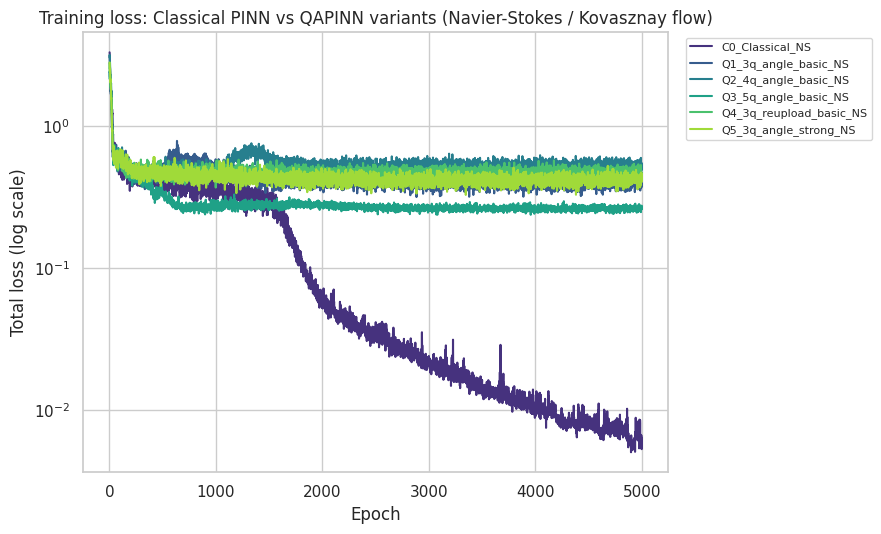

In [19]:
# ============================================================
# Loss curves -- all experiments, log scale
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["total"], label=name, ax=ax, linewidth=1.5)
ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Total loss (log scale)")
ax.set_title("Training loss: Classical PINN vs QAPINN variants (Navier-Stokes / Kovasznay flow)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("ns_loss_curves.png", dpi=150)
plt.show()

**Reading the output:** given the coupled, nonlinear, vector-valued nature of this system, expect slower and
noisier convergence than either companion notebook -- this is the hardest optimization landscape of the three.
If QAPINN variants plateau earlier than `C0` here too, that is the strongest version yet of the companion
notebooks' finding (generalizes even to a fully coupled system); if QAPINN keeps pace here despite the added
difficulty, that is an equally valid and notable result.

## Cell 9 — Gradient Diagnostics: Variance & Norm vs Epoch (Whole-Model)

Identical structure to the companion notebooks' Cell 9 -- the whole-model (classical + quantum combined)
`grad_variance`/`grad_norm` across training.

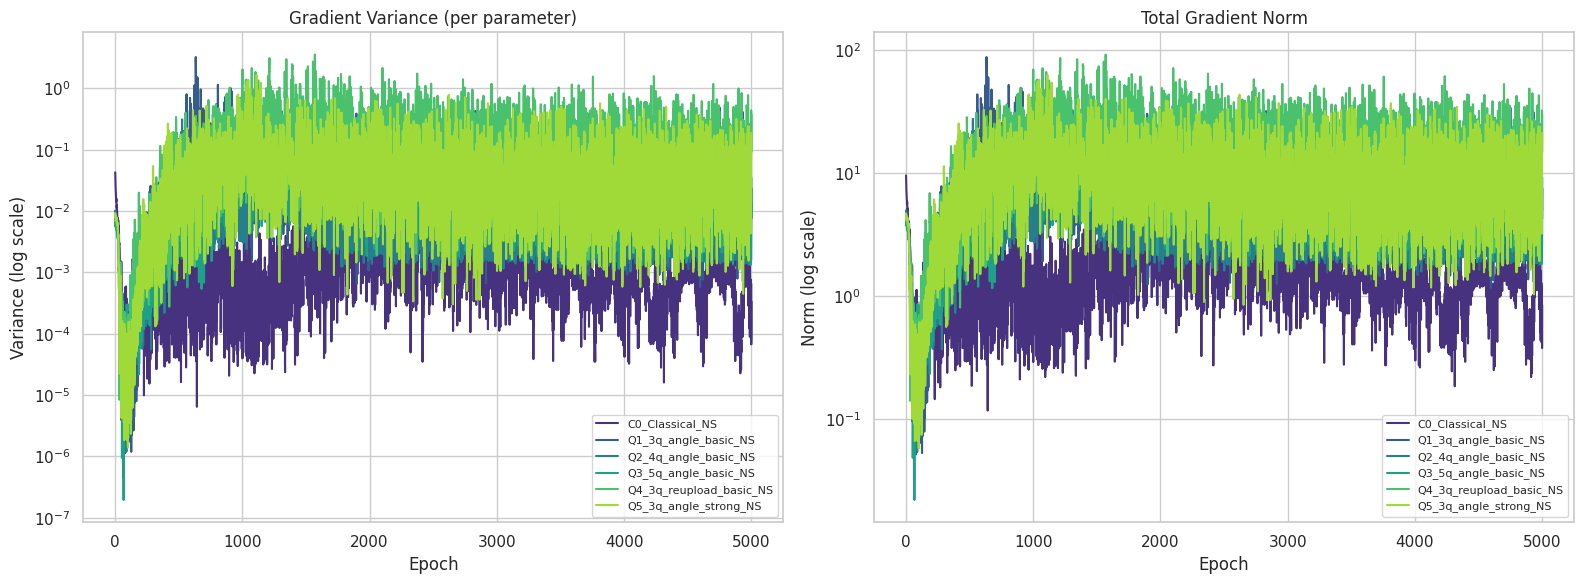

In [20]:
# ============================================================
# Gradient diagnostics: Variance and Norm vs Epoch
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_variance"], label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["grad_norm"], label=name, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Total Gradient Norm")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Norm (log scale)")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("ns_gradient_diagnostics.png", dpi=150)
plt.show()

**Reading the output:** as with the companion notebooks, don't use this whole-model metric alone for claims about the quantum layer specifically -- see the isolated quantum-only version added later in this notebook.

## Cell 10 — Final Loss, Parameter Count, and Training Time Comparison

Identical structure to the companion notebooks' Cell 10.

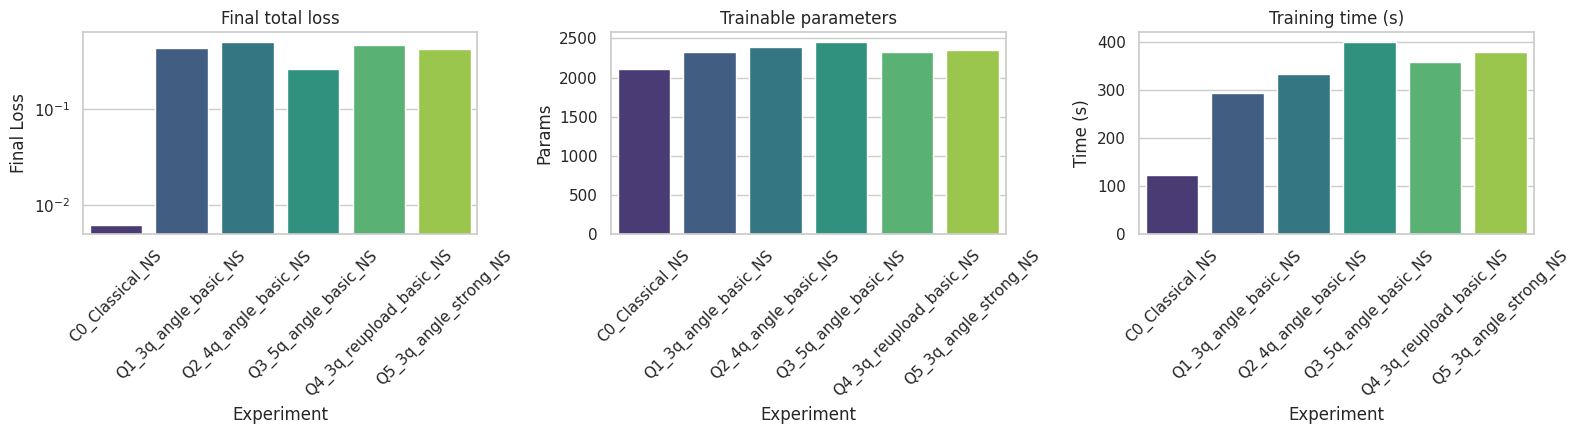

In [21]:
# ============================================================
# Final loss, parameter count, and training time comparison
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.barplot(data=summary_df, x="Experiment", y="Final Loss", hue="Experiment", ax=axes[0], legend=False)
axes[0].set_yscale("log")
axes[0].set_title("Final total loss")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Params", hue="Experiment", ax=axes[1], legend=False)
axes[1].set_title("Trainable parameters")
axes[1].tick_params(axis="x", rotation=45)

sns.barplot(data=summary_df, x="Experiment", y="Time (s)", hue="Experiment", ax=axes[2], legend=False)
axes[2].set_title("Training time (s)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("ns_comparison_bars.png", dpi=150)
plt.show()

**Reading the output:** the middle panel (params) should look roughly flat; the right panel (time) will show QAPINN taking longer, roughly increasing with qubit count, same pattern as the companion notebooks.

## Cell 11 — XAI Suite: Fourier Spectrum Analysis + McClean Barren-Plateau Scan

Both XAI techniques from the companion notebooks, unchanged in method, with **one adaptation specific to this
PDE**: the end-to-end Fourier sweep is taken along **`y` at a fixed `x`** rather than along `x` at a fixed `t` --
because the Kovasznay exact solution's oscillatory structure (`cos(2πy)`, `sin(2πy)`) lives in `y`, not `x`
(which instead varies smoothly/exponentially via `e^{λx}`). Expect the circuit-only spectrum to show its
strongest content near frequency ≈ 1 (the exact solution's fundamental wavenumber in `y`).

Uses the **corrected** McClean scan methodology from the start (a non-zero fixed input, `π/4`) -- an all-zero
fixed input makes `AngleEmbedding` degenerate to the identity gate, silently making `"angle"` and `"reupload"`
encoding produce the identical circuit at that input; this notebook applies that lesson from the outset.

**Fourier spectrum analysis** (Schuld et al.): `end_to_end_spectrum` (the full trained model's `u`-channel
output spectrum, swept over `y`) and `circuit_only_spectrum` (the isolated quantum layer's spectrum, via a
coherently swept encoding angle -- independent of the classical `input_projection`).

**McClean-style gradient variance scan**: variance of `∂cost/∂θ₀` across 100 random weight initializations at
the fixed, non-zero input, holding architecture fixed -- purely a property of the quantum circuit, unaffected by
which PDE it's attached to.

--- 1. Generating Fourier Spectrum Plots ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


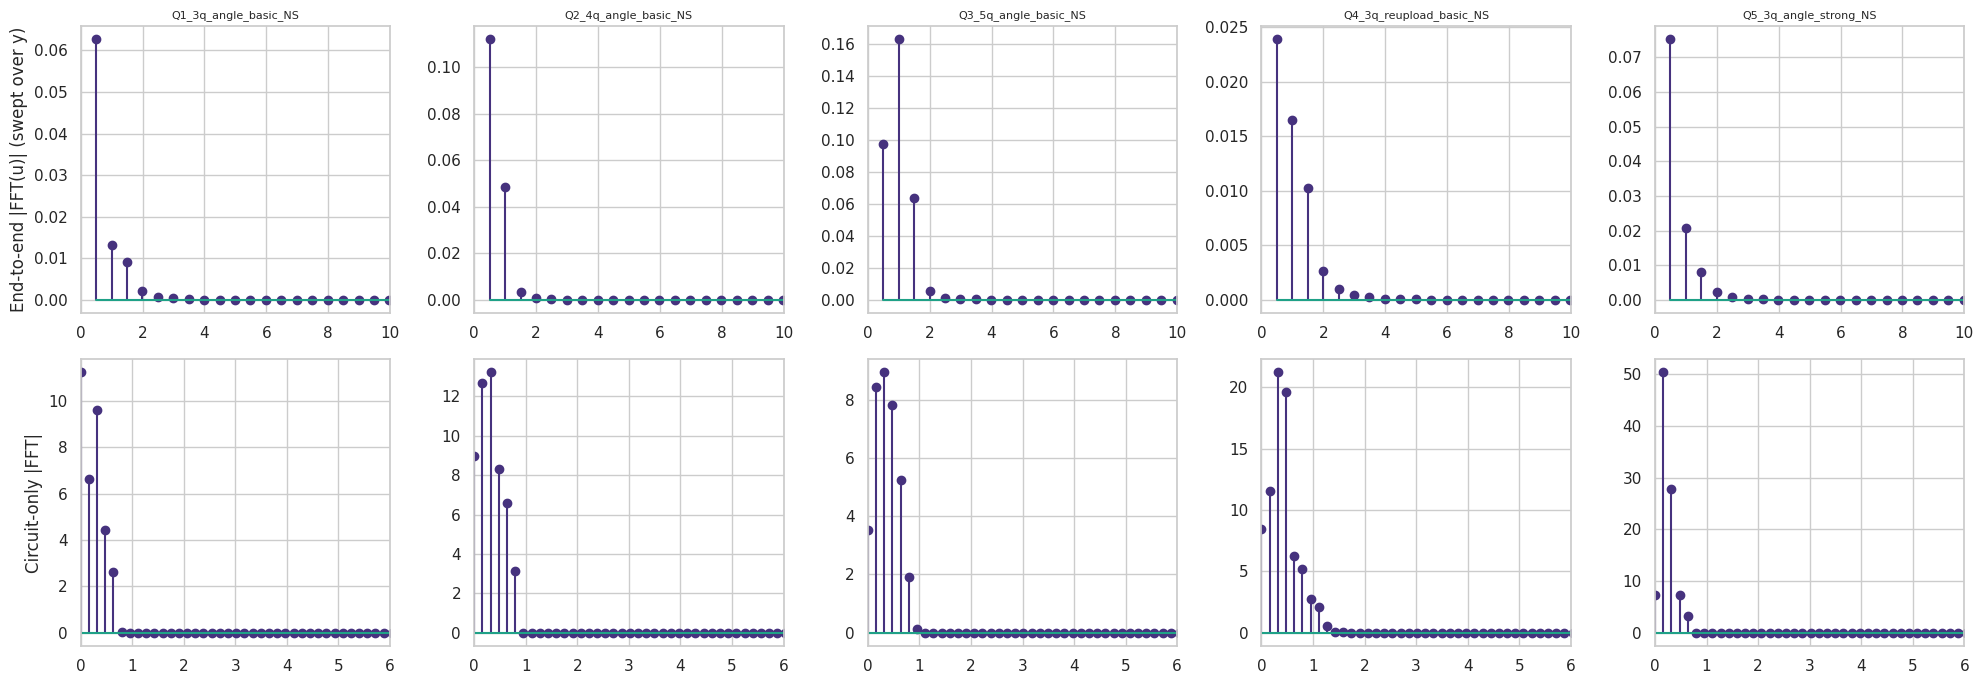

--- Circuit-only spectral summary (isolates VQC, swept angle) ---
             Experiment  Centroid   Spread  SignificantBins  MaxSignificantFreq
Q4_3q_reupload_basic_NS  0.409580 0.288928                8            1.111856
   Q3_5q_angle_basic_NS  0.358708 0.229869                6            0.794183
   Q2_4q_angle_basic_NS  0.318896 0.234346                6            0.794183
   Q1_3q_angle_basic_NS  0.230061 0.229376                5            0.635347
  Q5_3q_angle_strong_NS  0.233226 0.144713                5            0.635347

--- 2. Running McClean-style gradient variance scan ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


             Experiment  McClean_Variance
   Q1_3q_angle_basic_NS          0.246395
   Q2_4q_angle_basic_NS          0.028704
   Q3_5q_angle_basic_NS          0.032064
Q4_3q_reupload_basic_NS          0.082018
  Q5_3q_angle_strong_NS          0.060056


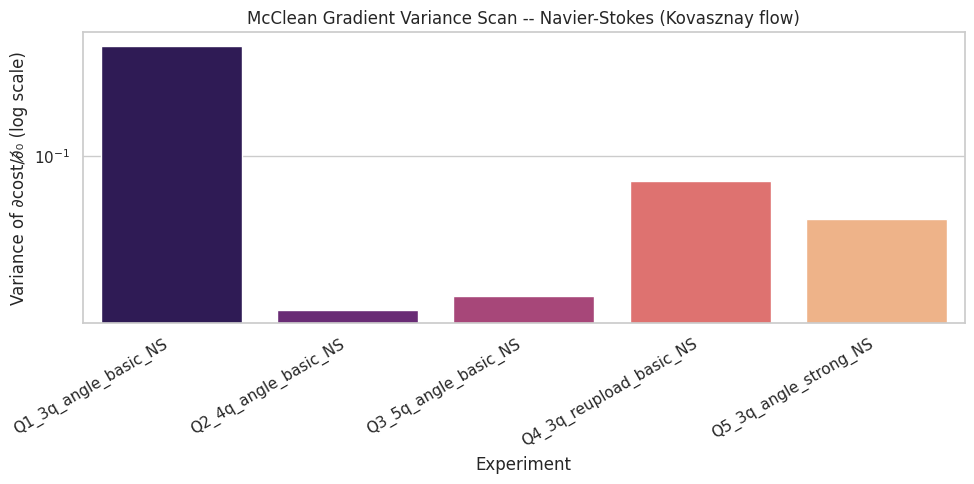

In [22]:
# ============================================================
# XAI Suite: Fourier spectrum (corrected, swept over y) + McClean
# barren-plateau scan, looped over all 5 QAPINN experiments.
# ============================================================
ALL_CONFIGS = {e["name"]: e for e in EXPERIMENTS}
loaded_models = {name: r["model"] for name, r in results.items()}


def end_to_end_spectrum(model, x_fixed=0.25, n_points=500):
    """Sweeps y at a fixed x and FFTs the model's u-channel output --
    y is the periodic direction for Kovasznay flow (cos/sin(2*pi*y))."""
    y_vals = torch.linspace(PHYSICS_CONFIG["y_min"], PHYSICS_CONFIG["y_max"], n_points).reshape(-1, 1)
    x_vals = torch.full((n_points, 1), x_fixed)
    model.eval()
    with torch.no_grad():
        u_pred = model(x_vals.to(GPU_DEVICE), y_vals.to(GPU_DEVICE)).cpu().numpy()[:, 0]
    u_pred_detrended = u_pred - np.mean(u_pred)
    window = np.hanning(n_points)
    fft_result = np.fft.fft(u_pred_detrended * window)
    frequencies = np.fft.fftfreq(n_points, d=(y_vals[1] - y_vals[0]).item())
    positive_freq_idx = frequencies > 0
    f_e2e = frequencies[positive_freq_idx]
    m_e2e = np.abs(fft_result[positive_freq_idx]) / n_points
    sort_idx = np.argsort(f_e2e)
    return f_e2e[sort_idx], m_e2e[sort_idx]


def circuit_only_spectrum(model, n_points=500):
    """Sweeps a coherent encoding angle theta in [-pi, pi] through the
    trained quantum layer and FFTs the resulting output -- the Schuld
    et al. test for a VQC's accessible Fourier spectrum. Independent of
    the PDE -- identical method and code to the companion notebooks."""
    if not hasattr(model, "quantum_layer"):
        return np.array([]), np.array([])
    n_qubits = model.n_qubits
    theta = np.linspace(-np.pi, np.pi, n_points)
    outputs = []
    model.eval()
    with torch.no_grad():
        for th in theta:
            inp = torch.full((1, n_qubits), th, dtype=torch.float32)
            out = model.quantum_layer(inp).squeeze(0)
            outputs.append(out.mean().item())
    outputs = np.array(outputs)
    signal = outputs - outputs.mean()
    window = np.hanning(n_points)
    fft_result = np.fft.rfft(signal * window)
    frequencies = np.fft.rfftfreq(n_points, d=(theta[1] - theta[0]))
    return frequencies, np.abs(fft_result)


N_SAMPLES = 100

def mcclean_variance_scan(n_qubits, n_qlayers, encoding, ansatz, n_samples=N_SAMPLES, seed=0):
    """build_qnode now returns a JAX-interface QNode, so gradients here
    come from jax.grad instead of torch autograd -- same experiment
    (random weight draws, fixed non-zero input, variance of
    d(cost)/d(theta_0)), just computed with JAX end to end."""
    qnode = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    fixed_input = jnp.full((n_qubits,), 0.7854)  # pi/4

    def cost_fn(weights):
        # Fix: Stack list of expvals into a single array before summing for jax.grad
        return jnp.sum(jnp.stack(qnode(fixed_input, weights)))

    grad_fn = jax.jit(jax.grad(cost_fn))
    key = jax.random.PRNGKey(seed)
    grads = []
    for _ in range(n_samples):
        key, subkey = jax.random.split(key)
        w = jax.random.normal(subkey, weight_shape)
        g = grad_fn(w)
        grads.append(float(np.asarray(g).flatten()[0]))
    return np.var(grads) if grads else 0.0


qapinn_names = [n for n, c in ALL_CONFIGS.items() if c["kind"] == "qapinn"]

print("--- 1. Generating Fourier Spectrum Plots ---")
fig, axes = plt.subplots(2, len(qapinn_names), figsize=(4 * len(qapinn_names), 7))
fourier_summary = []
for i, name in enumerate(qapinn_names):
    model = loaded_models[name]
    f_e2e, m_e2e = end_to_end_spectrum(model)
    axes[0, i].stem(f_e2e, m_e2e)
    axes[0, i].set_title(name, fontsize=8)
    axes[0, i].set_xlim(0, 10)

    f_c, m_c = circuit_only_spectrum(model)
    axes[1, i].stem(f_c, m_c)
    axes[1, i].set_xlim(0, 6)

    if m_c.sum() > 0:
        mag_norm = m_c / m_c.sum()
        centroid = float(np.sum(f_c * mag_norm))
        spread = float(np.sqrt(np.sum(((f_c - centroid) ** 2) * mag_norm)))
        n_sig = int(np.sum(m_c > 0.05 * m_c.max()))
        max_sig_freq = float(f_c[m_c > 0.05 * m_c.max()].max()) if n_sig > 0 else 0.0
    else:
        centroid = spread = n_sig = max_sig_freq = 0.0

    fourier_summary.append({
        "Experiment": name, "Centroid": centroid, "Spread": spread,
        "SignificantBins": n_sig, "MaxSignificantFreq": max_sig_freq,
    })

axes[0, 0].set_ylabel("End-to-end |FFT(u)| (swept over y)")
axes[1, 0].set_ylabel("Circuit-only |FFT|")
plt.tight_layout()
plt.savefig("ns_xai_fourier.png", dpi=150)
plt.show()

fourier_df = pd.DataFrame(fourier_summary).sort_values("MaxSignificantFreq", ascending=False)
print("--- Circuit-only spectral summary (isolates VQC, swept angle) ---")
print(fourier_df.to_string(index=False))

print("\n--- 2. Running McClean-style gradient variance scan ---")
mcclean_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
    mcclean_results.append({"Experiment": name, "McClean_Variance": var})

mcclean_df = pd.DataFrame(mcclean_results)
print(mcclean_df.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=mcclean_df, x="Experiment", y="McClean_Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("McClean Gradient Variance Scan -- Navier-Stokes (Kovasznay flow)")
plt.ylabel("Variance of ∂cost/∂̸₀ (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("ns_xai_mcclean.png", dpi=150)
plt.show()

**Reading the output:** compare `Q1` vs `Q3` (qubit-count axis) directly against the companion notebooks'
equivalent numbers -- since the circuits are architecturally identical, close agreement across all three
notebooks is strong evidence the qubit-count trainability effect is a property of the QAPINN architecture
itself, not specific to any one PDE (including this fully coupled system). Also check whether any configuration
combines a wide Fourier spectrum with a collapsed McClean variance -- that combination is the McClean-sense
barren-plateau signature (expressive in theory, untrainable in practice).

### Robustness Check — McClean Variance Under Wider Weight Initialization (Q5 Focus)

Same purpose as the companion notebooks' equivalent cell: re-runs the McClean scan for `Q5`
(`strongly_entangling`, the deepest ansatz) at two weight scales, to check whether a collapsed variance -- if
observed -- is a genuine, scale-independent barren plateau or an initialization-range artifact.

In [23]:
# ============================================================
# Robustness check: Q5 McClean variance at two weight-init scales
# ============================================================
def mcclean_variance_robustness_test(n_qubits, n_qlayers, encoding, ansatz, scale=1.0, n_samples=100, seed=1):
    """Same JAX-based gradient computation as mcclean_variance_scan above,
    with a scale factor applied to the random weight draws."""
    qnode = build_qnode(n_qubits, n_qlayers, encoding, ansatz)
    weight_shape = (n_qlayers, n_qubits, 3) if ansatz == "strongly_entangling" else (n_qlayers, n_qubits)
    fixed_input = jnp.full((n_qubits,), 0.7854)

    def cost_fn(weights):
        return jnp.sum(jnp.stack(qnode(fixed_input, weights)))

    grad_fn = jax.jit(jax.grad(cost_fn))
    key = jax.random.PRNGKey(seed)
    grads = []
    for _ in range(n_samples):
        key, subkey = jax.random.split(key)
        w = jax.random.normal(subkey, weight_shape) * scale
        g = grad_fn(w)
        grads.append(float(np.asarray(g).flatten()[0]))
    return np.var(grads) if grads else 0.0


q5_cfg = ALL_CONFIGS["Q5_3q_angle_strong_NS"]

print("--- Robustness Check: Q5 Gradient Variance under Different Scalings ---")
var_standard = mcclean_variance_robustness_test(q5_cfg["n_qubits"], 3, q5_cfg["encoding"], q5_cfg["ansatz"], scale=1.0)
var_pi = mcclean_variance_robustness_test(q5_cfg["n_qubits"], 3, q5_cfg["encoding"], q5_cfg["ansatz"], scale=np.pi)

print(f"Q5 Variance (Scale=1.0): {var_standard:.2e}")
print(f"Q5 Variance (Scale=PI):  {var_pi:.2e}")

if var_pi < 1e-12 and var_standard < 1e-12:
    print("\nRESULT: Gradient collapse persists under wide initialization. Robust barren plateau.")
elif abs(var_pi - var_standard) / max(var_standard, 1e-12) < 2.0:
    print("\nRESULT: Variance is consistent across both scales (whether collapsed or not) -- not an init-scale artifact.")
else:
    print(f"\nRESULT: Variance changed substantially with scale ({var_standard:.2e} -> {var_pi:.2e}) -- treat any collapse as scale-dependent, not a robust barren plateau.")

--- Robustness Check: Q5 Gradient Variance under Different Scalings ---


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


Q5 Variance (Scale=1.0): 8.86e-02
Q5 Variance (Scale=PI):  7.27e-02

RESULT: Variance is consistent across both scales (whether collapsed or not) -- not an init-scale artifact.


**Reading the output:** consistent results across both scales -- whether collapsed or normal -- rules out initialization range as the explanation either way. Don't claim a barren plateau (or its absence) is robust without this check.

### Seed-Robustness Check Across All 5 QAPINN Configs

Extends the single-seed McClean scan to 5 additional seeds, for every QAPINN configuration -- identical purpose
to the companion notebooks' equivalent cell.

Q1_3q_angle_basic_NS         | mean=2.464e-01 | std=0.000e+00 | min=2.464e-01 | max=2.464e-01
Q2_4q_angle_basic_NS         | mean=2.870e-02 | std=0.000e+00 | min=2.870e-02 | max=2.870e-02
Q3_5q_angle_basic_NS         | mean=3.206e-02 | std=0.000e+00 | min=3.206e-02 | max=3.206e-02
Q4_3q_reupload_basic_NS      | mean=8.202e-02 | std=0.000e+00 | min=8.202e-02 | max=8.202e-02
Q5_3q_angle_strong_NS        | mean=6.006e-02 | std=0.000e+00 | min=6.006e-02 | max=6.006e-02


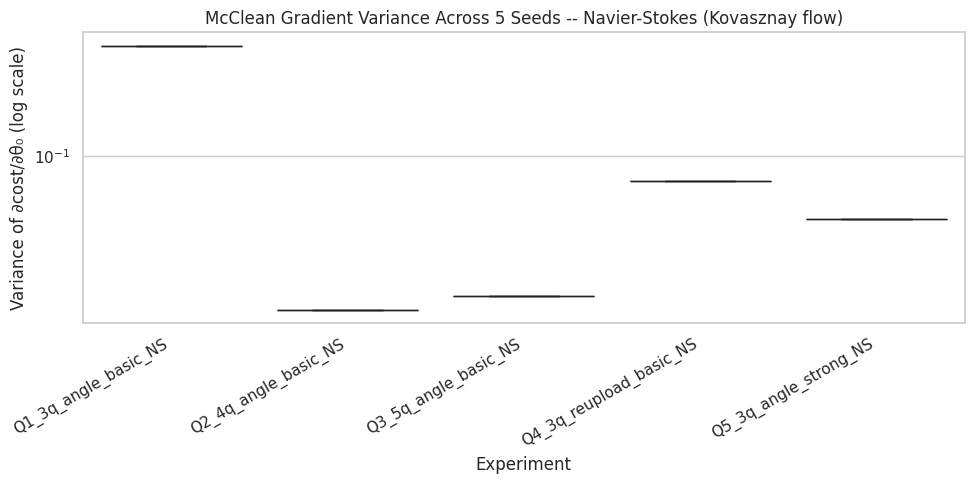


--- Seed-robustness summary ---
                             mean  std       min       max
Experiment                                                
Q1_3q_angle_basic_NS     0.246395  0.0  0.246395  0.246395
Q2_4q_angle_basic_NS     0.028704  0.0  0.028704  0.028704
Q3_5q_angle_basic_NS     0.032064  0.0  0.032064  0.032064
Q4_3q_reupload_basic_NS  0.082018  0.0  0.082018  0.082018
Q5_3q_angle_strong_NS    0.060056  0.0  0.060056  0.060056


In [24]:
# ============================================================
# Seed-robustness check for the McClean gradient variance scan,
# across ALL 5 QAPINN configs.
# ============================================================
ROBUSTNESS_SEEDS = [11, 29, 47, 71, 97]

seed_robustness_results = []
for name in qapinn_names:
    cfg = ALL_CONFIGS[name]
    seed_vars = []
    for seed in ROBUSTNESS_SEEDS:
        torch.manual_seed(seed)
        var = mcclean_variance_scan(cfg["n_qubits"], 3, cfg["encoding"], cfg["ansatz"])
        seed_vars.append(var)
        seed_robustness_results.append({"Experiment": name, "Seed": seed, "McClean_Variance": var})

    seed_vars = np.array(seed_vars)
    print(f"{name:28s} | mean={seed_vars.mean():.3e} | std={seed_vars.std():.3e} | "
          f"min={seed_vars.min():.3e} | max={seed_vars.max():.3e}")

torch.manual_seed(SEED)  # restore the global seed

seed_robustness_df = pd.DataFrame(seed_robustness_results)

plt.figure(figsize=(10, 5))
sns.boxplot(data=seed_robustness_df, x="Experiment", y="McClean_Variance",
            hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title(f"McClean Gradient Variance Across {len(ROBUSTNESS_SEEDS)} Seeds -- Navier-Stokes (Kovasznay flow)")
plt.ylabel("Variance of ∂cost/∂θ₀ (log scale)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("ns_xai_mcclean_seed_robustness.png", dpi=150)
plt.show()

seed_summary_df = seed_robustness_df.groupby("Experiment")["McClean_Variance"].agg(["mean", "std", "min", "max"])
print("\n--- Seed-robustness summary ---")
print(seed_summary_df.to_string())


**Reading the output:** compare this mean/std table directly against the companion notebooks' equivalent -- per-config agreement across all three notebooks is the clearest cross-PDE generalization evidence in this project.

## XAI Technique 3 — Activation Maps over the (x, y) Domain

Identical purpose and method to the companion notebooks, adapted to the 2D spatial domain (no time axis here).
Since the exact solution is periodic (`cos`/`sin(2πy)`) in `y` and smooth/exponential in `x`, a well-converged
representation should show clear banding along `y` and smoother, monotonic-looking variation along `x` -- a
useful three-way contrast with Burgers' (sharp `x`-localized shock feature) and heat (smooth decay in `t` only).

classical torch.Size([3600, 25]) torch.float32 cpu


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


qapinn torch.Size([3600, 3]) torch.float32 cpu
qapinn torch.Size([3600, 4]) torch.float32 cpu
qapinn torch.Size([3600, 5]) torch.float32 cpu
qapinn torch.Size([3600, 3]) torch.float32 cpu
qapinn torch.Size([3600, 3]) torch.float32 cpu


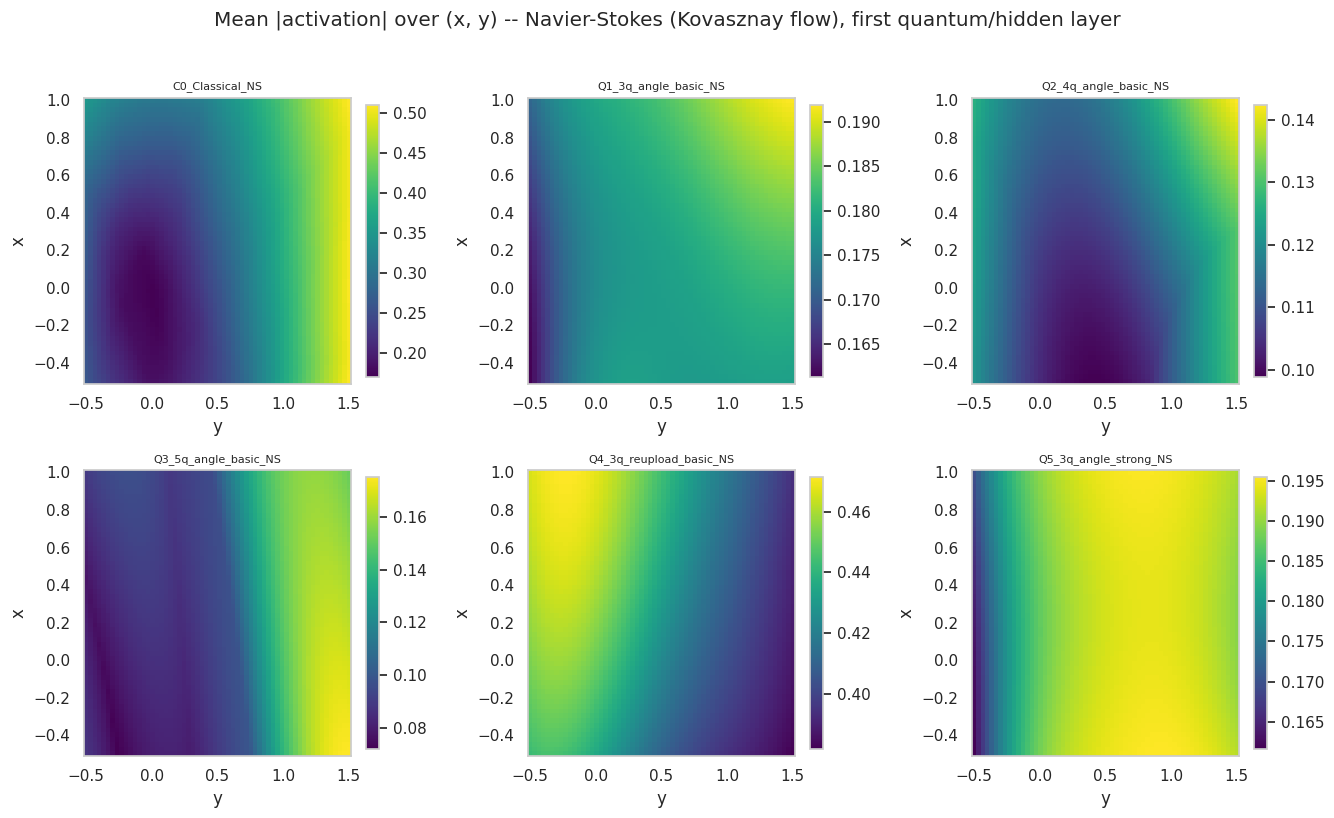

--- Activation map summary (sorted by spatial variability) ---
             Experiment  MeanActivation  StdActivation  MaxActivation  CoeffOfVariation
        C0_Classical_NS        0.313102       0.097085       0.510093          0.310073
   Q3_5q_angle_basic_NS        0.113307       0.032518       0.175099          0.286996
   Q2_4q_angle_basic_NS        0.114904       0.009471       0.142407          0.082429
Q4_3q_reupload_basic_NS        0.429188       0.025791       0.471348          0.060093
  Q5_3q_angle_strong_NS        0.189094       0.007486       0.195461          0.039588
   Q1_3q_angle_basic_NS        0.178718       0.005408       0.191878          0.030260


In [25]:
import torch

# ============================================================
# Activation maps: mean |activation| over (x, y) grid
# ============================================================
def get_activation_map(model, kind, n_grid=60, device=GPU_DEVICE):
    x_vals = torch.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], n_grid)
    y_vals = torch.linspace(PHYSICS_CONFIG["y_min"], PHYSICS_CONFIG["y_max"], n_grid)
    xx, yy = torch.meshgrid(x_vals, y_vals, indexing="ij")
    x_flat = xx.reshape(-1, 1).to(device)
    y_flat = yy.reshape(-1, 1).to(device)

    captured = {}
    def hook(mod, inp, out):
        captured["val"] = out.detach().cpu()

    if kind == "qapinn":
        handle = model.quantum_layer.register_forward_hook(hook)
    else:
        handle = model.net[1].register_forward_hook(hook)

    model.eval()
    with torch.no_grad():
        _ = model(x_flat, y_flat)
    handle.remove()

    act = captured["val"]
    print(kind,act.shape,act.dtype,act.device)
    n_points = x_flat.shape[0]
    if act.dim() == 2 and act.shape[0] == n_points:
      pass
    elif act.dim() == 2 and act.shape[1] == n_points:
        act = act.T
    else:
      raise RuntimeError(f"Unexpected activation shape {tuple(act.shape)} for {kind}")
    mean_act = act.abs().mean(dim=1).reshape(n_grid, n_grid).numpy()
    return xx.numpy(), yy.numpy(), mean_act


n_models = len(ALL_CONFIGS)
ncols = 3
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows))
axes = axes.flatten()

activation_summary = []
for i, (name, cfg) in enumerate(ALL_CONFIGS.items()):
    model = loaded_models[name]
    xx, yy, act_map = get_activation_map(model, cfg["kind"])

    im = axes[i].pcolormesh(yy, xx, act_map, shading="auto", cmap="viridis")
    axes[i].set_title(name, fontsize=8)
    axes[i].set_xlabel("y")
    axes[i].set_ylabel("x")
    plt.colorbar(im, ax=axes[i], fraction=0.046)

    activation_summary.append({
        "Experiment": name,
        "MeanActivation": float(act_map.mean()),
        "StdActivation": float(act_map.std()),
        "MaxActivation": float(act_map.max()),
        "CoeffOfVariation": float(act_map.std() / (act_map.mean() + 1e-12)),
    })

for j in range(len(ALL_CONFIGS), len(axes)):
    axes[j].axis("off")

plt.suptitle("Mean |activation| over (x, y) -- Navier-Stokes (Kovasznay flow), first quantum/hidden layer", y=1.02)
plt.tight_layout()
plt.savefig("ns_xai_activation_maps.png", dpi=150)
plt.show()

activation_df = pd.DataFrame(activation_summary).sort_values("CoeffOfVariation", ascending=False)
print("--- Activation map summary (sorted by spatial variability) ---")
print(activation_df.to_string(index=False))

**Reading the output:** expect visible periodic banding along `y` for a well-converged model; a map that is flat in *both* `x` and `y` is the red flag here -- even a poorly-trained model should pick up at least the dominant `y`-periodicity, since it's the strongest single feature of the exact solution.

### Quick Weight-Scale Check *(superseded — see the next cell for the definitive test)*

Same caveat as the companion notebooks: compares final trained weights against a *fresh, unrelated* random
tensor, not the model's own pre-training weights -- informative for absolute scale only, not for "did weights
move."

In [26]:
# ============================================================
# Quick weight-scale check (scale only, see caveat above)
# ============================================================
for name in qapinn_names:
    model = loaded_models[name]
    final_w = dict(model.quantum_layer.named_parameters())["weights"].detach()
    print(f"{name}: final weight std={final_w.std().item():.4f}, final weight norm={final_w.norm().item():.4f}")


Q1_3q_angle_basic_NS: final weight std=1.0897, final weight norm=4.7609
Q2_4q_angle_basic_NS: final weight std=1.5237, final weight norm=5.0576
Q3_5q_angle_basic_NS: final weight std=2.1046, final weight norm=7.9217
Q4_3q_reupload_basic_NS: final weight std=1.9112, final weight norm=5.4057
Q5_3q_angle_strong_NS: final weight std=2.0878, final weight norm=10.6455


**Reading the output:** compare scale only. `Q5` has 3x the parameters per layer of the `basic_entangler` configs, so a higher norm here is expected regardless of training.

### Definitive Weight-Movement Check for Q5 (Standalone Retrain with Logged Initialization)

Same method as the companion notebooks: a fresh `Q5` instance, weights logged before and after training, to
directly test whether the quantum layer's parameters actually moved. Given how much harder this coupled system
is to optimize, this is a particularly useful cross-notebook contrast for whether Q5's quantum layer engages
meaningfully as problem difficulty increases.

In [27]:
# ============================================================
# Definitive weight-movement check for Q5
# ============================================================
q5_model = QAPINN(n_qubits=3, n_qlayers=3, classical_hidden=(25, 25, 25, 25),
                   encoding="angle", ansatz="strongly_entangling")
q5_model.to(GPU_DEVICE)

init_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Init weight norm: {init_w.norm().item():.4f}")

history, elapsed = train(q5_model, epochs=TRAIN_CONFIG["epochs"], device=GPU_DEVICE, log_every=5)

final_w = dict(q5_model.quantum_layer.named_parameters())["weights"].detach().clone()
print(f"Final weight norm: {final_w.norm().item():.4f}")

delta = (final_w - init_w).norm().item()
rel_change = delta / init_w.norm().item()
print(f"Weight delta norm: {delta:.4f} | relative change: {rel_change:.2%}")

if rel_change < 0.05:
    print("Weights barely moved (<5% relative change) -- consistent with an untrained/frozen circuit.")
else:
    print("Weights moved meaningfully -- the quantum layer participated actively in training on this PDE.")


Init weight norm: 9.1110


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


[  12.4s] Epoch     1/5000 | total=2.455165 momentum=0.000003 continuity=0.000001 bc=2.455160 | grad_var=7.27e-03 | q_var=2.79e-03
[  12.7s] Epoch     5/5000 | total=2.094872 momentum=0.000002 continuity=0.000001 bc=2.094868 | grad_var=6.53e-03 | q_var=2.36e-03
[  13.0s] Epoch    10/5000 | total=1.764134 momentum=0.000001 continuity=0.000003 bc=1.764130 | grad_var=5.56e-03 | q_var=1.68e-03
[  13.8s] Epoch    15/5000 | total=1.556476 momentum=0.000001 continuity=0.000005 bc=1.556470 | grad_var=5.52e-03 | q_var=1.43e-03
[  14.2s] Epoch    20/5000 | total=1.256031 momentum=0.000003 continuity=0.000005 bc=1.256023 | grad_var=5.24e-03 | q_var=1.25e-03
[  14.5s] Epoch    25/5000 | total=0.841032 momentum=0.000004 continuity=0.000005 bc=0.841023 | grad_var=2.50e-03 | q_var=6.17e-04
[  14.8s] Epoch    30/5000 | total=0.671540 momentum=0.000006 continuity=0.000003 bc=0.671531 | grad_var=5.21e-04 | q_var=1.42e-04
[  15.2s] Epoch    35/5000 | total=0.602900 momentum=0.000006 continuity=0.000002 b

**Reading the output:** this is a fresh, differently-seeded run -- its `final_loss` won't exactly match the
official `Q5` row in `summary_df` and shouldn't be cited as if it does; only the weight-delta finding should be
quoted from this cell. Compare the relative-change percentage directly against the companion notebooks'
equivalent numbers.

## Cell 12 — Final Gradient Variance Comparison (Whole-Model, End of Training)

Identical to the companion notebooks' Cell 12 -- the coarsest of the three "variance" metrics in this notebook;
prefer the quantum-only or McClean metrics for quantum-specific claims.

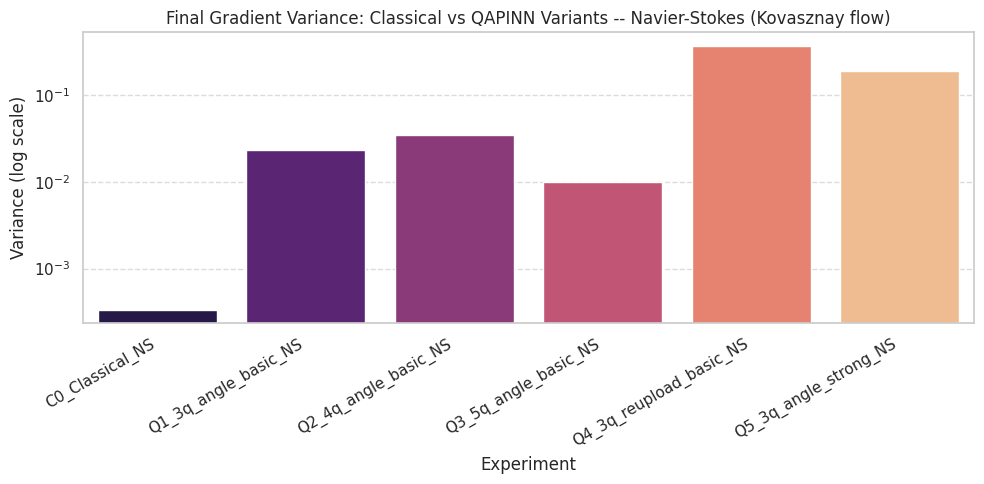

In [28]:
# ============================================================
# Comparison of Final Gradient Variance (whole-model)
# ============================================================
final_vars = []
for name, r in results.items():
    final_vars.append({"Experiment": name, "Final Gradient Variance": r["history"]["grad_variance"][-1]})
final_var_df = pd.DataFrame(final_vars)

plt.figure(figsize=(10, 5))
sns.barplot(data=final_var_df, x="Experiment", y="Final Gradient Variance", hue="Experiment", palette="magma", legend=False)
plt.yscale("log")
plt.title("Final Gradient Variance: Classical vs QAPINN Variants -- Navier-Stokes (Kovasznay flow)")
plt.ylabel("Variance (log scale)")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("ns_final_grad_variance.png", dpi=150)
plt.show()


**Reading the output:** whole-model metric, mixes classical and quantum gradients -- don't use alone for quantum-specific claims.

## Quantum-Layer-Only Gradient Variance Across Training

Same addition as the companion notebooks -- the isolated quantum-layer gradient variance across training,
plotted on its own rather than mixed into the whole-model metric above.

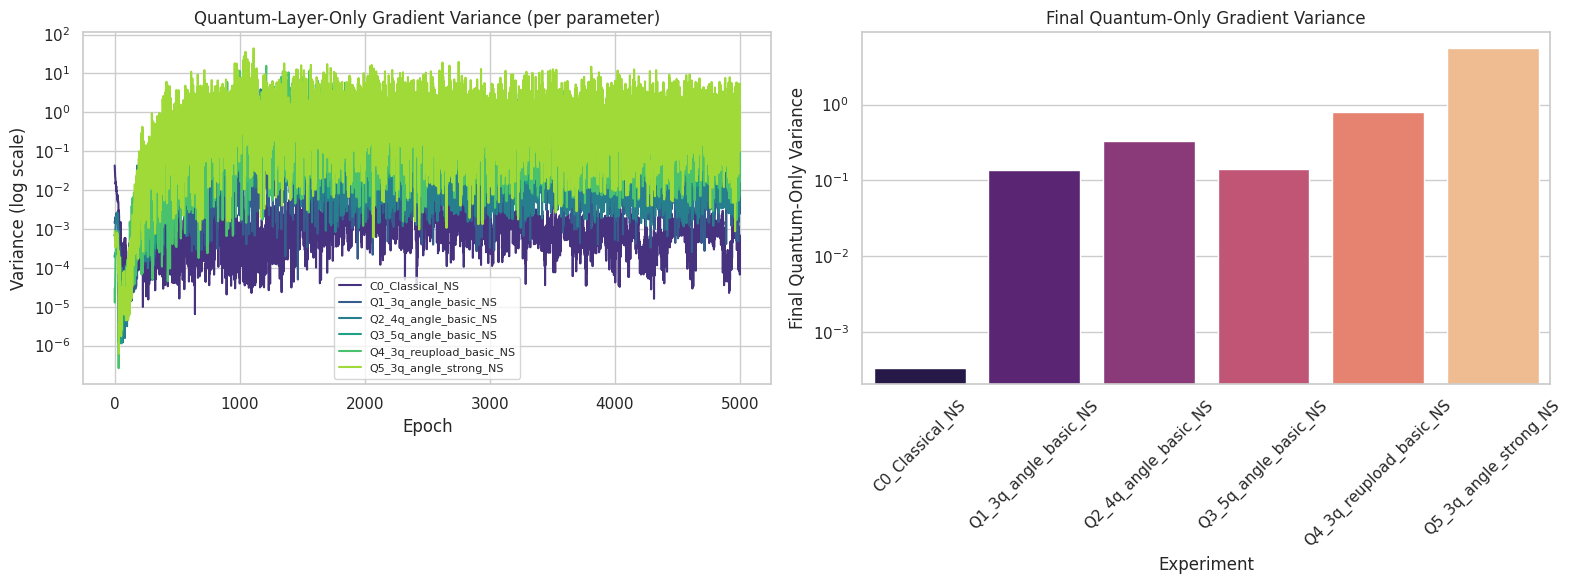

             Experiment  Final Quantum-Only Variance
        C0_Classical_NS                     0.000334
   Q1_3q_angle_basic_NS                     0.138506
   Q2_4q_angle_basic_NS                     0.325867
   Q3_5q_angle_basic_NS                     0.139414
Q4_3q_reupload_basic_NS                     0.786957
  Q5_3q_angle_strong_NS                     5.512759


In [29]:
# ============================================================
# Quantum-layer-only gradient variance across training
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for name, r in results.items():
    sns.lineplot(x=r["history"]["epoch"], y=r["history"]["quantum_grad_variance"], label=name, ax=axes[0])
axes[0].set_yscale("log")
axes[0].set_title("Quantum-Layer-Only Gradient Variance (per parameter)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Variance (log scale)")
axes[0].legend(fontsize=8)

final_q_vars = pd.DataFrame([
    {"Experiment": name, "Final Quantum-Only Variance": r["history"]["quantum_grad_variance"][-1]}
    for name, r in results.items() if "quantum_grad_variance" in r["history"]
])
sns.barplot(data=final_q_vars, x="Experiment", y="Final Quantum-Only Variance",
            hue="Experiment", palette="magma", legend=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Final Quantum-Only Gradient Variance")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("ns_quantum_only_grad_variance.png", dpi=150)
plt.show()

print(final_q_vars.to_string(index=False))


**Reading the output:** cross-reference against the McClean scan (Cell 11) -- agreement between the two, computed completely differently, is stronger evidence than either alone. Also directly comparable to the companion notebooks' equivalent numbers per configuration.

## Classical-Best Baseline

Same purpose as the companion notebooks: a classical PINN trained through the same pipeline for much longer, to
distinguish "QAPINN is parameter-efficient" from "QAPINN is competitive with the best classical model." **Note
the difference from the companion notebooks**: because this notebook uses `[25,25,25,25]` uniformly for every
model per this study's instructions, `C0_Best_Classical_NS` is the *same width* as `C0_Classical_NS`, not wider
-- its only advantage is `EPOCHS_CLASSICAL_BEST` vs `EPOCHS_MAIN` training time. Interpret its results as "does
more training time alone help," not "does more capacity help."

In [30]:
# ============================================================
# Classical-Best baseline
# ============================================================
classical_best_cfg = dict(name="C0_Best_Classical_NS", kind="classical")

def run_classical_best(cfg, epochs=EPOCHS_CLASSICAL_BEST):
    print("=" * 80)
    print(f"Running {cfg['name']} ({epochs} epochs)")
    print("=" * 80)
    model = ClassicalPINN(layers=(2, 25, 25, 25, 25, 3))
    history, elapsed = train(model, epochs=epochs, device=GPU_DEVICE, log_every=LOG_EVERY_N_EPOCHS)
    torch.save(model.state_dict(), f"{cfg['name']}.pt")
    return {
        "name": cfg["name"], "qubits": "-", "encoding": "-", "ansatz": "-",
        "params": model.num_params(), "final_loss": history["total"][-1],
        "time_s": elapsed, "history": history, "model": model,
    }

results["C0_Best_Classical_NS"] = run_classical_best(classical_best_cfg)

summary_df = pd.DataFrame([
    {"Experiment": r["name"], "Qubits": r["qubits"], "Encoding": r["encoding"],
     "Ansatz": r["ansatz"], "Params": r["params"],
     "Final Loss": r["final_loss"], "Time (s)": round(r["time_s"], 2)}
    for r in results.values()
])
summary_df.to_csv("qapinn_ns_results.csv", index=False)
summary_df


Running C0_Best_Classical_NS (10000 epochs)
[   0.0s] Epoch     1/10000 | total=2.170487 momentum=0.005529 continuity=0.004096 bc=2.160862 | grad_var=2.42e-02 | q_var=2.42e-02
[   0.3s] Epoch    10/10000 | total=1.783891 momentum=0.006799 continuity=0.009125 bc=1.767967 | grad_var=1.45e-02 | q_var=1.45e-02
[   0.6s] Epoch    20/10000 | total=1.122076 momentum=0.002912 continuity=0.005223 bc=1.113940 | grad_var=7.46e-03 | q_var=7.46e-03
[   0.9s] Epoch    30/10000 | total=0.703717 momentum=0.003003 continuity=0.002398 bc=0.698317 | grad_var=2.28e-03 | q_var=2.28e-03
[   1.2s] Epoch    40/10000 | total=0.588399 momentum=0.004467 continuity=0.004682 bc=0.579251 | grad_var=1.90e-04 | q_var=1.90e-04
[   1.5s] Epoch    50/10000 | total=0.536429 momentum=0.004078 continuity=0.004198 bc=0.528153 | grad_var=1.82e-04 | q_var=1.82e-04
[   1.8s] Epoch    60/10000 | total=0.548309 momentum=0.002163 continuity=0.001723 bc=0.544423 | grad_var=1.16e-04 | q_var=1.16e-04
[   2.2s] Epoch    70/10000 | to

,Experiment,Qubits,Encoding,Ansatz,Params,Final Loss,Time (s)
0,C0_Classical_NS,-,-,-,2103,0.006191,124.08
1,Q1_3q_angle_basic_NS,3,angle,basic_entangler,2332,0.436162,293.36
2,Q2_4q_angle_basic_NS,4,angle,basic_entangler,2393,0.509544,333.73
3,Q3_5q_angle_basic_NS,5,angle,basic_entangler,2454,0.263073,400.16
4,Q4_3q_reupload_basic_NS,3,reupload,basic_entangler,2332,0.472906,359.12
5,Q5_3q_angle_strong_NS,3,angle,strongly_entangling,2350,0.430536,379.53
6,C0_Best_Classical_NS,-,-,-,2103,0.002384,257.92


**Reading the output:** compare `C0_Best_Classical_NS`'s loss against both `C0_Classical_NS` and the QAPINN rows, using the same Decision Rules framework as the companion notebooks (reproduced in Notes at the end) -- remembering that here it differs only in training time, not width.

## Accuracy Benchmark: Verified Exact Reference Solution

Scores every trained model against the Kovasznay flow exact solution `(u, v, p)` -- verified symbolically with
SymPy before this notebook was written (continuity and both momentum residuals reduce to exactly zero when the
exact solution is substituted in, confirmed at `Re=40`). Reports a combined relative-L2 error over the full
`(u, v, p)` vector (for cross-notebook and Stage-C comparability with the single-scalar metric used in the
companion notebooks), plus a per-field breakdown -- since combining three physically different quantities into
a single number can hide a large error in one field being offset by a small error in another two.

In [31]:
# ============================================================
# Accuracy benchmark against the exact solution
# ============================================================
def get_reference_solution(nx=160, ny=120):
    x = np.linspace(PHYSICS_CONFIG["x_min"], PHYSICS_CONFIG["x_max"], nx)
    y = np.linspace(PHYSICS_CONFIG["y_min"], PHYSICS_CONFIG["y_max"], ny)
    XX, YY = np.meshgrid(x, y)

    x_torch = torch.tensor(XX.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    y_torch = torch.tensor(YY.flatten(), dtype=torch.float32).reshape(-1, 1).to(GPU_DEVICE)
    uvp_ref_torch = exact_solution(x_torch, y_torch)

    return x_torch, y_torch, XX, YY, uvp_ref_torch


def calculate_metrics(model, x_ref, y_ref, uvp_ref_vals):
    model.eval()
    with torch.no_grad():
        pred = model(x_ref, y_ref).cpu().numpy()
    ref = uvp_ref_vals.detach().cpu().numpy()

    mse = np.mean((ref - pred) ** 2)
    l2_rel = np.linalg.norm(ref.flatten() - pred.flatten()) / np.linalg.norm(ref.flatten())
    max_err = np.max(np.abs(ref - pred))

    field_rel_l2 = {}
    for i, fname in enumerate(["u", "v", "p"]):
        num = np.linalg.norm(ref[:, i] - pred[:, i])
        den = np.linalg.norm(ref[:, i])
        field_rel_l2[fname] = num / den if den > 0 else float("nan")

    return mse, l2_rel, max_err, field_rel_l2


x_torch, y_torch, XX, YY, uvp_reference = get_reference_solution()

final_metrics = []
for name, r in results.items():
    mse, l2_rel, max_err, field_rel_l2 = calculate_metrics(r["model"], x_torch, y_torch, uvp_reference)
    final_metrics.append({
        "Experiment": name, "Rel L2 Error (u,v,p)": f"{l2_rel:.4e}",
        "RelL2_u": f"{field_rel_l2['u']:.4e}", "RelL2_v": f"{field_rel_l2['v']:.4e}",
        "RelL2_p": f"{field_rel_l2['p']:.4e}",
        "Max Error": f"{max_err:.4e}", "Momentum Loss": f"{r['history']['pde'][-1]:.4e}",
        "Params": r["params"], "Time (s)": round(r["time_s"], 2),
        "Q-Variance": f"{r['history']['quantum_grad_variance'][-1]:.2e}" if "quantum_grad_variance" in r["history"] else "-",
    })

benchmark_df = pd.DataFrame(final_metrics)
benchmark_df


/usr/local/lib/python3.12/dist-packages/jax/_src/numpy/array_methods.py:125: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in astype is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)


,Experiment,"Rel L2 Error (u,v,p)",RelL2_u,RelL2_v,RelL2_p,Max Error,Momentum Loss,Params,Time (s),Q-Variance
0,C0_Classical_NS,1.3203e+00,4.8264e-02,1.5731e-01,4.7857e+00,1.7095e+00,2.5982e-03,2103,124.08,3.34e-04
1,Q1_3q_angle_basic_NS,5.5958e-01,4.9347e-01,1.1000e+00,1.0385e+00,1.7671e+00,3.6137e-02,2332,293.36,1.39e-01
2,Q2_4q_angle_basic_NS,6.3524e-01,5.8707e-01,1.2578e+00,1.0078e+00,2.0168e+00,5.4409e-02,2393,333.73,3.26e-01
3,Q3_5q_angle_basic_NS,4.3137e-01,3.3022e-01,1.3417e+00,9.9055e-01,1.0018e+00,7.4272e-02,2454,400.16,1.39e-01
4,Q4_3q_reupload_basic_NS,5.2961e-01,4.6886e-01,1.0193e+00,9.7439e-01,1.6491e+00,1.0452e-01,2332,359.12,7.87e-01
5,Q5_3q_angle_strong_NS,5.7432e-01,5.0888e-01,1.0906e+00,1.0553e+00,1.8465e+00,5.4137e-02,2350,379.53,5.51e+00
6,C0_Best_Classical_NS,1.1316e+00,2.0973e-02,6.7829e-02,4.1036e+00,1.4611e+00,1.3828e-03,2103,257.92,8.00e-05


**Reading the output:** given how much harder this coupled system is than the companion notebooks' scalar
PDEs, expect noticeably higher Rel L2 error across the board (for both classical baselines and QAPINN variants)
than either companion notebook -- this is expected, not necessarily a red flag by itself. Check the per-field
columns: pressure (`RelL2_p`) is frequently the hardest field to fit in Navier-Stokes PINNs (it's only
constrained indirectly, through its gradient in the momentum equations, never directly via a boundary condition
in this setup) -- a much higher `RelL2_p` than `RelL2_u`/`RelL2_v` across every row would be consistent with that
known pattern, not a bug.

**Decision-rule reference (same as the companion notebooks):**

| Rule | Condition | Conclusion |
|---|---|---|
| 1 | QAPINN beats **both** `C0_Classical_NS` and `C0_Best_Classical_NS` | Strong evidence for a genuinely useful quantum configuration |
| 2 | QAPINN beats only `C0_Classical_NS` (parameter-matched) | Evidence for parameter efficiency, not best achievable accuracy |
| 3 | QAPINN has lower training loss but higher Rel L2 Error | Not a solution-quality win -- investigate loss weighting/imbalance |
| 4 | QAPINN is less accurate and slower | Report as a negative result, honestly |
| 5 | More qubits/depth improve accuracy but cost grows rapidly | Report the accuracy-cost trade-off, not a free advantage |
| 6 | Result varies a lot across seeds | Report as unstable/inconclusive |

## Stage C — Multi-Seed Statistical Confirmation (5 Seeds)

Identical structure to the companion notebooks' Stage C: re-runs the original 6-experiment matrix across 5
independent seeds, scores each run against the exact solution (combined `u,v,p` Rel L2, for comparability with
the single-scalar metric used elsewhere), and statistically tests whether each QAPINN variant's accuracy differs
from classical. `C0_Best_Classical_NS` is excluded from this sweep, same reasoning as the companion notebooks.

> ⚠️ **This cell trains 6 experiments × 5 seeds = 30 full training runs.** Gated off by default
> (`RUN_STAGE_C = False`, set in the Local Run Configuration cell) -- given this notebook's higher per-epoch
> cost (three coupled residual equations vs one), this is likely the **most expensive** Stage C run of the three
> PDE notebooks. Opt in only if you have real time to spare.

Streaming output truncated to the last 5000 lines.
[  19.7s] Epoch   790/5000 | total=0.325511 momentum=0.009007 continuity=0.001534 bc=0.314970 | grad_var=2.62e-05 | q_var=2.62e-05
[  19.9s] Epoch   800/5000 | total=0.363222 momentum=0.009827 continuity=0.001655 bc=0.351740 | grad_var=2.53e-05 | q_var=2.53e-05
[  20.1s] Epoch   810/5000 | total=0.353552 momentum=0.009155 continuity=0.002004 bc=0.342393 | grad_var=3.11e-04 | q_var=3.11e-04
[  20.4s] Epoch   820/5000 | total=0.299211 momentum=0.009611 continuity=0.001865 bc=0.287735 | grad_var=3.07e-05 | q_var=3.07e-05
[  20.6s] Epoch   830/5000 | total=0.367304 momentum=0.009160 continuity=0.001852 bc=0.356292 | grad_var=3.88e-04 | q_var=3.88e-04
[  20.9s] Epoch   840/5000 | total=0.352466 momentum=0.009432 continuity=0.002115 bc=0.340918 | grad_var=1.94e-04 | q_var=1.94e-04
[  21.1s] Epoch   850/5000 | total=0.336362 momentum=0.009228 continuity=0.001944 bc=0.325190 | grad_var=6.05e-04 | q_var=6.05e-04
[  21.3s] Epoch   860/5000 | tot

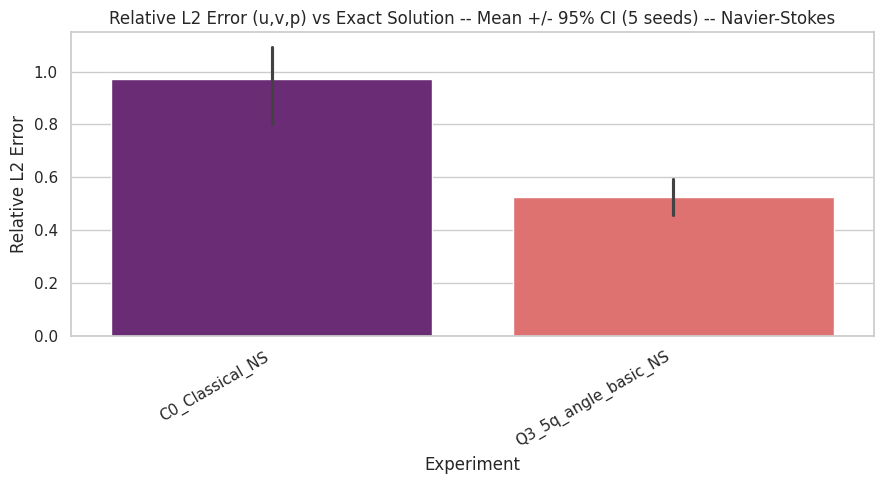


### SCIENTIFIC BENCHMARK MASTER TABLE (single-seed diagnostics) -- Navier-Stokes (Kovasznay flow) ###
             Experiment Qubits Encoding              Ansatz  Params  Total_Loss  Time_sec  Max_Freq_k  Spectral_Bins  McClean_BP_Var  Spatial_Act_CV
        C0_Classical_NS      -        -                   -    2103    0.006191    124.08         NaN            NaN             NaN        0.310073
   Q1_3q_angle_basic_NS      3    angle     basic_entangler    2332    0.436162    293.36    0.635347            5.0        0.246395        0.030260
   Q2_4q_angle_basic_NS      4    angle     basic_entangler    2393    0.509544    333.73    0.794183            6.0        0.028704        0.082429
   Q3_5q_angle_basic_NS      5    angle     basic_entangler    2454    0.263073    400.16    0.794183            6.0        0.032064        0.286996
Q4_3q_reupload_basic_NS      3 reupload     basic_entangler    2332    0.472906    359.12    1.111856            8.0        0.082018        0.060093
  Q

/usr/local/lib/python3.12/dist-packages/scipy/_lib/deprecation.py:234: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  return f(*args, **kwargs)


In [33]:
# ============================================================
# Stage C -- multi-seed statistical confirmation
# ============================================================
TARGET_SEEDS = [11, 29, 47, 71, 97]

def run_multi_seed_experiment(experiments, target_seeds):
    all_results = []
    print(f"Running {len(experiments)} experiments over {len(target_seeds)} seeds...")

    x_torch_s, y_torch_s, _, _, uvp_reference_s = get_reference_solution()

    for seed in target_seeds:
        print(f"\n--- Running with SEED: {seed} ---")
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        for exp_cfg in experiments:
            print(f"  Experiment: {exp_cfg['name']}")
            run_result = run_experiment(exp_cfg, epochs=TRAIN_CONFIG["epochs"])
            model = run_result["model"]

            mse, l2_rel, max_err, _ = calculate_metrics(model, x_torch_s, y_torch_s, uvp_reference_s)

            all_results.append({
                "Seed": seed, "Experiment": exp_cfg["name"],
                "Qubits": exp_cfg.get("n_qubits", "-"), "Encoding": exp_cfg.get("encoding", "-"),
                "Ansatz": exp_cfg.get("ansatz", "-"), "Params": model.num_params(),
                "Final_Loss": run_result["final_loss"], "Time_s": run_result["time_s"],
                "RelL2": l2_rel, "MaxErr": max_err, "PDE_Loss_Final": run_result["history"]["pde"][-1],
            })
    return pd.DataFrame(all_results)


if not RUN_STAGE_C:
    print("RUN_STAGE_C is False -- skipping the 30-run multi-seed sweep.")
    print("Set RUN_STAGE_C = True in the Local Run Configuration cell if you have time free.")
    multi_seed_df = None
else:
    # Filter experiments for Stage C based on user request
    stage_c_experiments = [
        exp for exp in EXPERIMENTS if exp["name"] in [
            "C0_Classical_NS", "Q3_5q_angle_basic_NS"]
    ]
    multi_seed_df = run_multi_seed_experiment(stage_c_experiments, TARGET_SEEDS)
    multi_seed_df.to_csv("stage_c_ns_statistical_data.csv", index=False)

    from scipy import stats as scipy_stats

    def summarize_with_ci(df, group_col, value_col, confidence=0.95):
        rows = []
        for name, g in df.groupby(group_col):
            vals = g[value_col].values
            n = len(vals)
            mean = vals.mean()
            std = vals.std(ddof=1) if n > 1 else 0.0
            if n > 1:
                sem = std / np.sqrt(n)
                ci_half = sem * scipy_stats.t.ppf((1 + confidence) / 2, n - 1)
            else:
                ci_half = 0.0
            rows.append({group_col: name, "N_seeds": n, "Mean": mean, "Std": std,
                         "CI95_Lower": mean - ci_half, "CI95_Upper": mean + ci_half})
        return pd.DataFrame(rows)

    rel_l2_summary = summarize_with_ci(multi_seed_df, "Experiment", "RelL2")
    print("\n--- Stage C: Relative L2 Error (u,v,p), mean +/- 95% CI across 5 seeds ---")
    print(rel_l2_summary.to_string(index=False))

    plt.figure(figsize=(9, 5))
    sns.barplot(data=multi_seed_df, x="Experiment", y="RelL2", hue="Experiment",
                palette="magma", legend=False, errorbar=("ci", 95))
    plt.title("Relative L2 Error (u,v,p) vs Exact Solution -- Mean +/- 95% CI (5 seeds) -- Navier-Stokes")
    plt.ylabel("Relative L2 Error")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig("ns_stage_c_rel_l2_ci.png", dpi=150)
    plt.show()

    master_report = summary_df[summary_df["Experiment"] != "C0_Best_Classical_NS"].copy()
    master_report = master_report.merge(fourier_df[["Experiment", "MaxSignificantFreq", "SignificantBins"]], on="Experiment", how="left")
    master_report = master_report.merge(mcclean_df[["Experiment", "McClean_Variance"]], on="Experiment", how="left")
    master_report = master_report.merge(activation_df[["Experiment", "CoeffOfVariation"]], on="Experiment", how="left")
    master_report.columns = ["Experiment", "Qubits", "Encoding", "Ansatz", "Params", "Total_Loss", "Time_sec",
                              "Max_Freq_k", "Spectral_Bins", "McClean_BP_Var", "Spatial_Act_CV"]
    print("\n### SCIENTIFIC BENCHMARK MASTER TABLE (single-seed diagnostics) -- Navier-Stokes (Kovasznay flow) ###")
    print(master_report.to_string(index=False))
    master_report.to_csv("qapinn_ns_scientific_deliverables.csv", index=False)

    from scipy.stats import ttest_ind
    n_comparisons = len([m for m in EXPERIMENTS if m["kind"] == "qapinn"])
    bonferroni_alpha = 0.05 / n_comparisons
    print(f"\n### Statistical Comparison vs Classical C0 (Welch's t-test, RelL2) ###")
    print(f"Uncorrected alpha = 0.05 | Bonferroni-corrected alpha = {bonferroni_alpha:.4f}")

    c0_scores = multi_seed_df[multi_seed_df["Experiment"] == "C0_Classical_NS"]["RelL2"].values
    sig_results = []
    for model_name in [m["name"] for m in EXPERIMENTS if m["kind"] == "qapinn"]:
        q_scores = multi_seed_df[multi_seed_df["Experiment"] == model_name]["RelL2"].values
        t_stat, p_val = ttest_ind(c0_scores, q_scores, equal_var=False)
        uncorrected = "Significant" if p_val < 0.05 else "Not Significant"
        corrected = "Significant" if p_val < bonferroni_alpha else "Not Significant"
        print(f"{model_name:28s} | p = {p_val:.4f} | uncorrected: {uncorrected:16s} | Bonferroni-corrected: {corrected}")
        sig_results.append({"Experiment": model_name, "p_value": p_val,
                             "Significant_Uncorrected": uncorrected, "Significant_Bonferroni": corrected})
    significance_df = pd.DataFrame(sig_results)

**Reading the output (if `RUN_STAGE_C = True`):** same reading strategy as the companion notebooks -- check
the mean±CI table for stability first, then the significance table (Bonferroni-corrected column is the
conservative, defensible one), then cross-reference against the gradient diagnostics above. If left `False`,
report single-seed results only and note the multi-seed confirmation wasn't run.

## Pointwise Error Map vs. Exact Solution

Same purpose as the companion notebooks: visualizes `|u_exact - u_predicted|` (the `u`-velocity component) across
the full `(x, y)` domain for a chosen configuration.

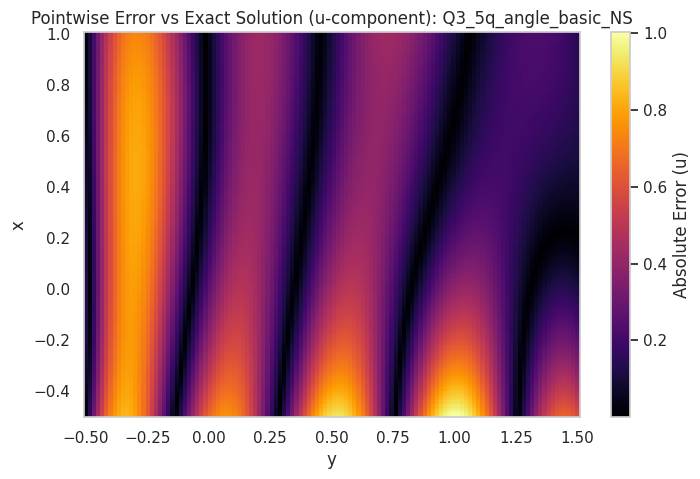

In [34]:
# ============================================================
# Pointwise error map (u-velocity component)
# ============================================================
target_q = "Q3_5q_angle_basic_NS"
model_q = results[target_q]["model"]

with torch.no_grad():
    u_q = model_q(x_torch, y_torch).cpu().numpy()[:, 0].reshape(XX.shape)
u_ref_plot = uvp_reference.cpu().numpy()[:, 0].reshape(XX.shape)
error_map = np.abs(u_ref_plot - u_q)

plt.figure(figsize=(8, 5))
plt.pcolormesh(YY, XX, error_map, cmap="inferno", shading="auto")
plt.colorbar(label="Absolute Error (u)")
plt.title(f"Pointwise Error vs Exact Solution (u-component): {target_q}")
plt.xlabel("y")
plt.ylabel("x")
plt.show()

**Reading the output:** unlike Burgers' (error concentrated near the shock) or heat (roughly uniform), expect
error here to track the domain's own structure -- often larger near `x_max` where `e^{λx}` (and hence the
solution's gradients) is smallest in magnitude but the boundary is furthest from where training emphasized
accuracy, or wherever the periodic `y`-structure is least well resolved. There's no shock to act as a natural
hotspot, but there is real spatial structure to check against.

### Notes

- **Full parity with the companion notebooks**: the full 6-config matrix, `C0_Best_Classical_NS`, whole-model and
  quantum-only gradient diagnostics, both Fourier and McClean XAI techniques (with the zero-input fix applied
  from the start), the weight-init-scale and 5-seed robustness checks, activation maps, the weight-movement
  check, the exact-solution accuracy benchmark, Stage C multi-seed statistics with Welch's t-test and Bonferroni
  correction, and the pointwise error map are all present here too.
- **What's genuinely different about this notebook**: (1) the PDE is a coupled, nonlinear, vector-valued system
  (continuity + 2 momentum equations, 3 outputs) rather than a single scalar equation; (2) the domain is 2D
  steady-state `(x, y)` rather than 1D time-dependent `(x, t)` -- there is no initial condition, and the
  `"ic"` loss term of the companion notebooks is replaced by `"continuity"` (mass conservation), a genuinely new
  physical constraint; (3) every classical hidden stack in this notebook uses `[25, 25, 25, 25]`, uniformly,
  instead of the companion notebooks' `[20, 20, 20, 20]` / `(20, 20, 20)`; (4) every training run logs every 10
  epochs instead of every `~epochs//5`.
- **Cross-notebook comparison is the main added value of this notebook**: `Q1`-`Q5`'s circuits are identical
  across the Burgers', heat, and this notebook. Put the McClean scan results from all three side by side in your
  report -- agreement is the strongest generalization evidence available from this project; disagreement is
  equally worth reporting, as evidence the effect is PDE-dependent.
- **Reproducibility scope**: the main matrix and most diagnostics are `SEED=42` single-seed; Stage C (if enabled)
  adds 5 further seeds for the accuracy metric specifically.
- **Exact-solution verification**: checked symbolically with SymPy before this notebook was written -- the
  continuity equation and both momentum equations reduce to exactly zero when the Kovasznay exact solution
  (at `Re=40`) is substituted in, and numeric spot-checks across the domain agree to floating-point precision.
- **Local CPU support**: `FAST_LOCAL_MODE`, `EPOCHS_MAIN`/`EPOCHS_CLASSICAL_BEST`, `RUN_STAGE_C`, and the Runtime
  Calibration cell all carry over the same CPU-backup design used in the companion notebooks -- this single
  notebook works on both a Colab GPU and a local CPU-only machine without modification.

**Report checklist** -- evidence gathered in this notebook, mapped to typical report sections:

- *Experiments*: `summary_df` -- final loss, parameter count, training time, all 7 configurations.
- *Results (accuracy)*: `benchmark_df` (single-seed, with `u`/`v`/`p` breakdown) + Stage C `rel_l2_summary`/
  significance table (multi-seed, if enabled) -- both against the true exact solution.
- *Explainability §1 (expressivity)*: circuit-only Fourier spectrum, `fourier_df`.
- *Explainability §2 (trainability)*: McClean scan, scale-robustness check, 5-seed cross-config robustness check,
  quantum-only gradient variance plot, weight-movement check.
- *Explainability §3 (what was learned)*: activation maps + pointwise error map (u-component).
- *Cross-PDE generalization*: side-by-side McClean/Fourier comparison against the Burgers' and heat notebooks for
  identical `Q1`-`Q5` architectures.
- *Limitations*: single-seed default, Bonferroni caveat if Stage C is run, `C0_Best_Classical_NS`'s different
  epoch budget (no longer a width advantage, per this notebook's uniform `[25,25,25,25]`), pressure typically
  harder to fit than velocity (no direct pressure BC), CPU/GPU training-time gap.